# Feature extraction notebook

# Dependencies

In [2]:
import pandas as pd
from sqlalchemy import create_engine
import tools.helpers as hh
import matplotlib.pyplot as plt
from matplotlib_venn import venn3
from venn import venn

In [3]:
pd.set_option('display.max_columns', None)

## load cohorts

In [4]:
#1.5k cohort
main_cohort_df= pd.read_csv("/Users/gnaanikko.pa/Documents/Academic /MIMIC/model_building/outputs/common_hadm_ids_1k.csv")


In [6]:
# df_resp_inf_icu= pd.read_parquet("/Users/gnaanikko.pa/Documents/Academic /MIMIC/model_building/outputs/df_resp_inf_icu_final.parq", engine="fastparquet")


In [8]:
lab_df= pd.read_parquet("/Users/gnaanikko.pa/Documents/Academic /MIMIC/model_building/outputs/common_resp_lab_icu_inf_df.parquet", engine="fastparquet")
ast_df= pd.read_parquet("/Users/gnaanikko.pa/Documents/Academic /MIMIC/model_building/outputs/common_resp_ast_icu_inf_df.parquet", engine="fastparquet")
pres_df= pd.read_parquet("/Users/gnaanikko.pa/Documents/Academic /MIMIC/model_building/outputs/common_resp_pres_icu_inf_df.parquet", engine="fastparquet")
emar_df= pd.read_parquet("/Users/gnaanikko.pa/Documents/Academic /MIMIC/model_building/outputs/common_resp_emar_icu_inf_df.parquet", engine="fastparquet")
input_df= pd.read_parquet("/Users/gnaanikko.pa/Documents/Academic /MIMIC/model_building/outputs/common_resp_input_icu_inf_df.parquet", engine="fastparquet")
micro_df= pd.read_parquet("/Users/gnaanikko.pa/Documents/Academic /MIMIC/model_building/outputs/common_resp_micro_icu_inf_df.parquet", engine="fastparquet")
lab_test_icu_df= pd.read_parquet("/Users/gnaanikko.pa/Documents/Academic /MIMIC/model_building/outputs/lab_test_icu_df.parq", engine="fastparquet")



FileNotFoundError: [Errno 2] No such file or directory: '/Users/gnaanikko.pa/Documents/Academic /MIMIC/model_building/outputs/common_resp_lab_icu_inf_df.parquet'

In [ ]:
admissions_df= pd.read_parquet("/Users/gnaanikko.pa/Documents/Academic /MIMIC/model_building/outputs/df_admissions.parq", engine="fastparquet")

In [ ]:
admissions_df = pd.read_parquet("/Users/gnaanikko.pa/Documents/Academic /MIMIC/model_building/outputs/df_admissions.parq", engine="fastparquet")

In [1]:
hh.dxx(admissions_df)

NameError: name 'hh' is not defined

In [12]:
hh.dxx(df_resp_inf_icu)

11.9k Unique Patient IDs (11905)
13.6k Unique Admission IDs (13611)
16.4k Unique ICU Stay IDs (16438)
18.1k Rows, shape: (18109, 6)



,subject_id,hadm_id,stay_id,seq_num,icd_version,icd_code
dtype,int64,int64,int64,int64,int64,object
NotNA | NA,18109 | 0,18109 | 0,18109 | 0,18109 | 0,18109 | 0,18109 | 0
nunique,11905,13611,16438,38,2,142
0,10001843,26133978,39698942,4,10,J189
1,10001884,26184834,37510196,19,10,J0190
2,10002155,20345487,32358465,2,9,486


<Axes: >

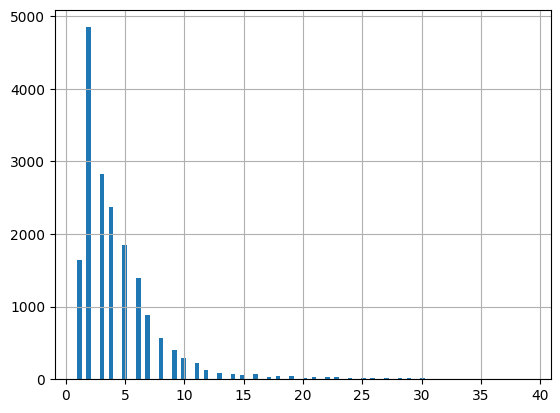

In [16]:
df_resp_inf_icu.seq_num.hist(bins=100)

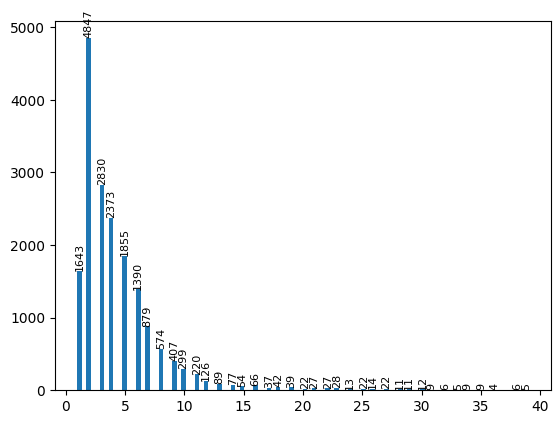

In [22]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots()

n, bins, patches = ax.hist(
    df_resp_inf_icu.seq_num.dropna(),
    bins=100
)

for count, patch in zip(n, patches):
    if count > 0:
        ax.text(
            patch.get_x() + patch.get_width() / 2,
            count,
            int(count),
            ha='center',
            va='bottom',
            fontsize=8,
            rotation=90
        )

plt.show()


In [28]:
df_resp_inf_icu.describe()

,subject_id,hadm_id,stay_id,seq_num,icd_version
count,1.810900e+04,1.810900e+04,1.810900e+04,18109.000000,18109.000000
mean,1.505339e+07,2.497291e+07,3.500587e+07,4.493180,9.568391
std,2.879499e+06,2.879779e+06,2.871629e+06,3.983942,0.495314
min,1.000184e+07,2.000092e+07,3.000015e+07,1.000000,9.000000
25%,1.257909e+07,2.249844e+07,3.254415e+07,2.000000,9.000000
50%,1.510224e+07,2.495883e+07,3.501890e+07,3.000000,10.000000
75%,1.758828e+07,2.741721e+07,3.749618e+07,6.000000,10.000000
max,1.999962e+07,2.999962e+07,3.999986e+07,39.000000,10.000000


In [20]:
hh.dxx(df_resp_inf_icu[df_resp_inf_icu.seq_num <=2 ])

5.2k Unique Patient IDs (5201)
5.7k Unique Admission IDs (5670)
6.5k Unique ICU Stay IDs (6454)
6.5k Rows, shape: (6490, 6)



,subject_id,hadm_id,stay_id,seq_num,icd_version,icd_code
dtype,int64,int64,int64,int64,int64,object
NotNA | NA,6490 | 0,6490 | 0,6490 | 0,6490 | 0,6490 | 0,6490 | 0
nunique,5201,5670,6454,2,2,116
2,10002155,20345487,32358465,2,9,486
3,10002155,23822395,33685454,2,9,486
4,10002155,28994087,31090461,1,9,486


In [20]:
ast_df[ast_df['stay_id']==30004391]

,subject_id,hadm_id,stay_id,first_careunit,charttime,spec_type_desc,test_name,org_name,ab_name,dilution_value,interpretation,comments
21914,18730522,21463350,30004391,Medical Intensive Care Unit (MICU),2153-09-05 14:48:00,SPUTUM,RESPIRATORY CULTURE,KLEBSIELLA PNEUMONIAE,CEFAZOLIN,4.00,S,Commensal Respiratory Flora Absent.
21930,18730522,21463350,30004391,Medical Intensive Care Unit (MICU),2153-09-05 14:48:00,SPUTUM,RESPIRATORY CULTURE,KLEBSIELLA PNEUMONIAE,TRIMETHOPRIM/SULFA,1.00,S,Commensal Respiratory Flora Absent.
21932,18730522,21463350,30004391,Medical Intensive Care Unit (MICU),2153-09-05 14:48:00,SPUTUM,RESPIRATORY CULTURE,KLEBSIELLA PNEUMONIAE,GENTAMICIN,1.00,S,Commensal Respiratory Flora Absent.
21937,18730522,21463350,30004391,Medical Intensive Care Unit (MICU),2153-09-05 14:48:00,SPUTUM,RESPIRATORY CULTURE,KLEBSIELLA PNEUMONIAE,TOBRAMYCIN,1.00,S,Commensal Respiratory Flora Absent.
21940,18730522,21463350,30004391,Medical Intensive Care Unit (MICU),2153-09-05 14:48:00,SPUTUM,RESPIRATORY CULTURE,KLEBSIELLA PNEUMONIAE,CEFTAZIDIME,1.00,S,Commensal Respiratory Flora Absent.
21941,18730522,21463350,30004391,Medical Intensive Care Unit (MICU),2153-09-05 14:48:00,SPUTUM,RESPIRATORY CULTURE,KLEBSIELLA PNEUMONIAE,CEFTRIAXONE,1.00,S,Commensal Respiratory Flora Absent.
21942,18730522,21463350,30004391,Medical Intensive Care Unit (MICU),2153-09-05 14:48:00,SPUTUM,RESPIRATORY CULTURE,KLEBSIELLA PNEUMONIAE,CIPROFLOXACIN,0.25,S,Commensal Respiratory Flora Absent.
21943,18730522,21463350,30004391,Medical Intensive Care Unit (MICU),2153-09-05 14:48:00,SPUTUM,RESPIRATORY CULTURE,KLEBSIELLA PNEUMONIAE,AMPICILLIN/SULBACTAM,4.00,S,Commensal Respiratory Flora Absent.
21944,18730522,21463350,30004391,Medical Intensive Care Unit (MICU),2153-09-05 14:48:00,SPUTUM,RESPIRATORY CULTURE,KLEBSIELLA PNEUMONIAE,PIPERACILLIN/TAZO,4.00,S,Commensal Respiratory Flora Absent.
21945,18730522,21463350,30004391,Medical Intensive Care Unit (MICU),2153-09-05 14:48:00,SPUTUM,RESPIRATORY CULTURE,KLEBSIELLA PNEUMONIAE,CEFEPIME,1.00,S,Commensal Respiratory Flora Absent.


In [16]:
hh.dxx(ast_df)

1.4k Unique Patient IDs (1433)
1.5k Unique Admission IDs (1512)
1.6k Unique ICU Stay IDs (1601)
25.4k Rows, shape: (25408, 12)



,subject_id,hadm_id,stay_id,first_careunit,charttime,spec_type_desc,test_name,org_name,ab_name,dilution_value,interpretation,comments
dtype,int64,int64,int64,object,datetime64[ns],object,object,object,object,float64,object,object
NotNA | NA,25408 | 0,25408 | 0,25408 | 0,25408 | 0,25408 | 0,25408 | 0,25408 | 0,25408 | 0,25408 | 0,24197 | 1211,25408 | 0,18527 | 6881
nunique,1433,1512,1601,14,2560,28,14,80,26,19,3,28
0,10005817,28661809,31316840,Medical/Surgical Intensive Care Unit (MICU/SICU),2135-01-08 15:30:00,MRSA SCREEN,MRSA SCREEN,STAPH AUREUS COAG +,ERYTHROMYCIN,nan,R,None
1,10005817,28661809,31316840,Medical/Surgical Intensive Care Unit (MICU/SICU),2135-01-08 15:30:00,MRSA SCREEN,MRSA SCREEN,STAPH AUREUS COAG +,CLINDAMYCIN,nan,R,None
2,10005817,28661809,31316840,Medical/Surgical Intensive Care Unit (MICU/SICU),2135-01-08 15:30:00,MRSA SCREEN,MRSA SCREEN,STAPH AUREUS COAG +,TRIMETHOPRIM/SULFA,0.500000,S,None


In [24]:
lab_test1k= lab_test_icu_df[lab_test_icu_df['hadm_id'].isin(main_cohort_df['hadm_id'])]

In [25]:
hh.dx(lab_test1k)

1.4k Unique Patient IDs (1432)
1.5k Unique Admission IDs (1511)
2.0k Unique ICU Stay IDs (2049)
1.7M Rows, shape: (1656388, 24)



In [26]:
hh.dx(lab_df)
hh.dx(ast_df)
hh.dx(pres_df)
hh.dx(emar_df) 
hh.dx(input_df)
hh.dx(micro_df)        

1.4k Unique Patient IDs (1433)
1.5k Unique Admission IDs (1512)
ICU Stay ID column not found.
2.2M Rows, shape: (2210094, 18)

1.4k Unique Patient IDs (1433)
1.5k Unique Admission IDs (1512)
1.6k Unique ICU Stay IDs (1601)
25.4k Rows, shape: (25408, 12)

1.4k Unique Patient IDs (1433)
1.5k Unique Admission IDs (1512)
2.1k Unique ICU Stay IDs (2065)
306.1k Rows, shape: (306138, 23)

1.4k Unique Patient IDs (1433)
1.5k Unique Admission IDs (1512)
2.0k Unique ICU Stay IDs (2030)
1.9M Rows, shape: (1943956, 19)

1.4k Unique Patient IDs (1433)
1.5k Unique Admission IDs (1512)
2.0k Unique ICU Stay IDs (2044)
1.1M Rows, shape: (1089897, 26)

1.4k Unique Patient IDs (1433)
1.5k Unique Admission IDs (1512)
1.9k Unique ICU Stay IDs (1865)
54.3k Rows, shape: (54320, 18)



# extracting values for feature space creation

In [7]:
hh.dxx(lab_df)

1.4k Unique Patient IDs (1433)
1.5k Unique Admission IDs (1512)
ICU Stay ID column not found.
2.2M Rows, shape: (2210094, 18)



,subject_id,hadm_id,labevent_id,specimen_id,itemid,label,fluid,category,charttime,storetime,value,valuenum,valueuom,ref_range_lower,ref_range_upper,flag,priority,comments
dtype,int64,int64,int64,int64,int64,object,object,object,datetime64[ns],datetime64[ns],object,float64,object,float64,float64,object,object,object
NotNA | NA,2210094 | 0,2210094 | 0,2210094 | 0,2210094 | 0,2210094 | 0,2210094 | 0,2210094 | 0,2210094 | 0,2210094 | 0,2203245 | 6849,2105599 | 104495,2033008 | 177086,1875257 | 334837,1774526 | 435568,1774526 | 435568,947530 | 1262564,1804262 | 405832,329130 | 1880964
nunique,1433,1512,2210094,233159,667,566,9,3,141366,331496,8771,9783,52,104,146,2,3,2161
0,10004733,27411876,83399,67503312,51484,Ketone,Urine,Hematology,2174-12-06 04:00:00,2174-12-06 04:51:00,None,nan,mg/dL,nan,nan,None,ROUTINE,NEG.
1,10004733,27411876,83400,67503312,51486,Leukocytes,Urine,Hematology,2174-12-06 04:00:00,2174-12-06 04:51:00,None,nan,None,nan,nan,None,ROUTINE,SM .
2,10004733,27411876,83401,67503312,51487,Nitrite,Urine,Hematology,2174-12-06 04:00:00,2174-12-06 04:51:00,None,nan,None,nan,nan,None,ROUTINE,NEG.


In [8]:
lab_df.label.value_counts()

label
Glucose                          73560
Sodium                           59670
Potassium                        59293
H                                59001
L                                58999
                                 ...  
Young Cells                          1
CD55                                 1
Non-squamous Epithelial Cells        1
Glucose, Urine                       1
Ammonium Biurate                     1
Name: count, Length: 566, dtype: int64

In [10]:
hh.dxx(admissions_df)

11.9k Unique Patient IDs (11905)
13.6k Unique Admission IDs (13611)
16.4k Unique ICU Stay IDs (16438)
16.4k Rows, shape: (16438, 16)



,subject_id,gender,anchor_age,anchor_year,hadm_id,hospital_admit_time,hospital_discharge_time,hospital_death_time,stay_id,icu_admit_time,icu_discharge_time,icu_los_days,admission_type,admission_location,discharge_location,race
dtype,int64,object,int64,int64,int64,datetime64[ns],datetime64[ns],datetime64[ns],int64,datetime64[ns],datetime64[ns],float64,object,object,object,object
NotNA | NA,16438 | 0,16438 | 0,16438 | 0,16438 | 0,16438 | 0,16438 | 0,16438 | 0,3620 | 12818,16438 | 0,16438 | 0,16429 | 9,16429 | 9,16438 | 0,16438 | 0,16405 | 33,16438 | 0
nunique,11905,2,73,96,13611,13607,13598,2831,16438,16438,16430,16246,9,11,14,33
0,10003637,M,57,2145,28317408,2150-05-14 19:51:00,2150-05-22 16:25:00,2150-05-22 16:25:00,32824762,2150-05-16 07:30:28,2150-05-22 18:38:55,6.464201,EW EMER.,WALK-IN/SELF REFERRAL,DIED,PORTUGUESE
1,10010888,M,43,2174,20162667,2174-01-09 22:19:00,2174-01-27 16:00:00,NaT,33318955,2174-01-09 00:21:00,2174-01-18 00:48:41,9.019225,EW EMER.,TRANSFER FROM HOSPITAL,HOME HEALTH CARE,WHITE
2,10011938,F,57,2121,23798746,2133-08-13 09:48:00,2133-10-05 19:27:00,NaT,31780787,2133-08-13 09:48:53,2133-09-01 18:22:42,19.356817,EW EMER.,TRANSFER FROM SKILLED NURSING FACILITY,REHAB,WHITE - OTHER EUROPEAN


In [11]:
icu_stay_df = admissions_df[["subject_id", "hadm_id", "stay_id", "icu_admit_time", "icu_discharge_time","icu_los_days"]]

In [12]:
hh.dxx(icu_stay_df)

11.9k Unique Patient IDs (11905)
13.6k Unique Admission IDs (13611)
16.4k Unique ICU Stay IDs (16438)
16.4k Rows, shape: (16438, 6)



,subject_id,hadm_id,stay_id,icu_admit_time,icu_discharge_time,icu_los_days
dtype,int64,int64,int64,datetime64[ns],datetime64[ns],float64
NotNA | NA,16438 | 0,16438 | 0,16438 | 0,16438 | 0,16429 | 9,16429 | 9
nunique,11905,13611,16438,16438,16430,16246
0,10003637,28317408,32824762,2150-05-16 07:30:28,2150-05-22 18:38:55,6.464201
1,10010888,20162667,33318955,2174-01-09 00:21:00,2174-01-18 00:48:41,9.019225
2,10011938,23798746,31780787,2133-08-13 09:48:53,2133-09-01 18:22:42,19.356817


In [13]:
icu_stay_df_final= icu_stay_df[icu_stay_df.hadm_id.isin(main_cohort_df.hadm_id.unique())]

In [14]:
admissions_df_final= admissions_df[admissions_df.hadm_id.isin(main_cohort_df.hadm_id.unique())]

In [19]:
#merge lab with icu stay to get only labs during icu stay 
lab_admissions = (
    lab_df.merge(icu_stay_df_final, on=["subject_id","hadm_id"], how="left", validate="many_to_many")
         .loc[lambda d: (d["charttime"] >= d["icu_admit_time"]) & (d["charttime"] < d["icu_discharge_time"])]
)

In [20]:
#select and reorder columns
lab_admissions=lab_admissions[['subject_id', 'hadm_id', 'stay_id','labevent_id', 'specimen_id', 'itemid', 'icu_admit_time', 'charttime', 'icu_discharge_time', 'icu_los_days',
       'label', 'fluid', 'category', 'storetime', 'value','valuenum', 'valueuom', 'ref_range_lower', 'ref_range_upper', 'flag', 'priority', 'comments']]

In [21]:
# after filtering events inside icu stays, the counts have from 2.1 M to 1.7M
hh.dxx(lab_admissions)

1.4k Unique Patient IDs (1432)
1.5k Unique Admission IDs (1511)


2.0k Unique ICU Stay IDs (2049)
1.7M Rows, shape: (1656388, 22)



,subject_id,hadm_id,stay_id,labevent_id,specimen_id,itemid,icu_admit_time,charttime,icu_discharge_time,icu_los_days,label,fluid,category,storetime,value,valuenum,valueuom,ref_range_lower,ref_range_upper,flag,priority,comments
dtype,int64,int64,int64,int64,int64,int64,datetime64[ns],datetime64[ns],datetime64[ns],float64,object,object,object,datetime64[ns],object,float64,object,float64,float64,object,object,object
NotNA | NA,1656388 | 0,1656388 | 0,1656388 | 0,1656388 | 0,1656388 | 0,1656388 | 0,1656388 | 0,1656388 | 0,1656388 | 0,1656388 | 0,1656388 | 0,1656388 | 0,1656388 | 0,1651727 | 4661,1585204 | 71184,1518076 | 138312,1396141 | 260247,1311130 | 345258,1311130 | 345258,713259 | 943129,1269143 | 387245,253504 | 1402884
nunique,1432,1511,2049,1656388,178882,630,2049,113612,2049,2046,548,9,3,264047,7948,8893,52,102,144,2,3,1751
0,10004733,27411876,39635619,83399,67503312,51484,2174-12-04 11:28:24,2174-12-06 04:00:00,2174-12-12 20:03:01,8.357373,Ketone,Urine,Hematology,2174-12-06 04:51:00,None,nan,mg/dL,nan,nan,None,ROUTINE,NEG.
1,10004733,27411876,39635619,83400,67503312,51486,2174-12-04 11:28:24,2174-12-06 04:00:00,2174-12-12 20:03:01,8.357373,Leukocytes,Urine,Hematology,2174-12-06 04:51:00,None,nan,None,nan,nan,None,ROUTINE,SM .
2,10004733,27411876,39635619,83401,67503312,51487,2174-12-04 11:28:24,2174-12-06 04:00:00,2174-12-12 20:03:01,8.357373,Nitrite,Urine,Hematology,2174-12-06 04:51:00,None,nan,None,nan,nan,None,ROUTINE,NEG.


In [22]:
# FILTER FOR FIRST 24 HOURS ONLY AFTER ICU ADMISSION
lab_admissions_24h = lab_admissions.loc[lambda d: (d["charttime"] < d["icu_admit_time"] + pd.Timedelta(hours=24))]
hh.dxx(lab_admissions_24h)

1.4k Unique Patient IDs (1427)
1.5k Unique Admission IDs (1505)
2.0k Unique ICU Stay IDs (2042)
245.8k Rows, shape: (245799, 22)



,subject_id,hadm_id,stay_id,labevent_id,specimen_id,itemid,icu_admit_time,charttime,icu_discharge_time,icu_los_days,label,fluid,category,storetime,value,valuenum,valueuom,ref_range_lower,ref_range_upper,flag,priority,comments
dtype,int64,int64,int64,int64,int64,int64,datetime64[ns],datetime64[ns],datetime64[ns],float64,object,object,object,datetime64[ns],object,float64,object,float64,float64,object,object,object
NotNA | NA,245799 | 0,245799 | 0,245799 | 0,245799 | 0,245799 | 0,245799 | 0,245799 | 0,245799 | 0,245799 | 0,245799 | 0,245799 | 0,245799 | 0,245799 | 0,244736 | 1063,229442 | 16357,218273 | 27526,207042 | 38757,190123 | 55676,190123 | 55676,105565 | 140234,183899 | 61900,47101 | 198698
nunique,1427,1505,2042,245799,25315,514,2042,15969,2042,2039,455,9,3,40382,4435,4698,46,96,135,2,3,804
3,10004733,27411876,39635619,83231,54857146,51237,2174-12-04 11:28:24,2174-12-04 13:01:00,2174-12-12 20:03:01,8.357373,INR(PT),Blood,Hematology,2174-12-04 17:16:00,1.3,1.300000,None,0.900000,1.100000,abnormal,ROUTINE,None
4,10004733,27411876,39635619,83232,54857146,51274,2174-12-04 11:28:24,2174-12-04 13:01:00,2174-12-12 20:03:01,8.357373,PT,Blood,Hematology,2174-12-04 17:16:00,14.6,14.600000,sec,9.400000,12.500000,abnormal,ROUTINE,None
5,10004733,27411876,39635619,83233,54857146,51275,2174-12-04 11:28:24,2174-12-04 13:01:00,2174-12-12 20:03:01,8.357373,PTT,Blood,Hematology,2174-12-04 17:01:00,34.1,34.100000,sec,25.000000,36.500000,None,ROUTINE,None


In [26]:
#get the first lab value in the first 24 hours
first_labs = (lab_admissions_24h.sort_values(["stay_id", "itemid", "charttime"]).groupby(["stay_id", "itemid"], as_index=False).first())




In [27]:
## 

In [158]:
lab_list=['Glucose','Sodium','Potassium','Chloride','Creatinine','Magnesium','Phosphate','Hemoglobin','Hematocrit','White Blood Cells']
# Python list
item_ids = [50983, 50971, 50902, 50931, 50912, 51222, 51221, 51301, 50960, 50970]


In [236]:
lab_dict={}
for item_id in item_ids:
    lab_dict[item_id]= first_labs[first_labs['itemid']==item_id]
    lab_dict[item_id]= lab_dict[item_id][['stay_id','valuenum']].rename(columns={'valuenum':f'{item_id}'}) 

In [237]:
# Get all keys
keys = list(lab_dict.keys())

# Start with the first dataframe
merged_df = lab_dict[keys[0]]

# Sequentially merge remaining dfs
for key in keys[1:]:
    merged_df = merged_df.merge(lab_dict[key], on="stay_id", how="left", suffixes=("", f"_{key}"))


In [238]:
merged_df

,stay_id,50983,50971,50902,50931,50912,51222,51221,51301,50960,50970
0,30004391,141.0,4.7,115.0,138.0,1.3,9.9,30.6,13.5,2.1,3.8
1,30004823,142.0,4.8,96.0,241.0,0.6,9.7,36.9,14.2,2.5,2.8
2,30016351,137.0,4.2,109.0,105.0,0.6,10.3,30.9,10.5,2.2,2.1
3,30017005,135.0,5.2,98.0,148.0,4.5,9.6,32.1,37.6,2.1,5.5
4,30023732,159.0,5.4,117.0,122.0,2.1,NaN,NaN,NaN,2.5,3.8
...,...,...,...,...,...,...,...,...,...,...,...
2020,39965130,140.0,4.6,102.0,137.0,2.1,10.5,32.8,53.4,3.2,6.0
2021,39966562,137.0,4.0,99.0,145.0,0.7,10.1,32.2,6.6,1.9,3.7
2022,39984768,126.0,2.4,61.0,106.0,0.3,8.9,27.4,11.8,3.5,2.9
2023,39986786,142.0,5.0,109.0,168.0,1.4,10.4,33.4,13.9,1.5,3.6


In [ ]:
# df_labs = pd.concat(lab_dict.values(), ignore_index=True)

In [245]:
# hh.dxx(df_labs)

In [246]:
# df_labs.itemid.value_counts()

In [163]:
# multiple values for same stay id for glucose, because it has different itemids, like urine glucose, blood glucose etc.

In [ ]:
# df_labs.isna().sum()

stay_id                   0
itemid                    0
subject_id                0
hadm_id                   0
labevent_id               0
specimen_id               0
icu_admit_time            0
charttime                 0
icu_discharge_time        0
icu_los_days              0
label                     0
fluid                     0
category                  0
storetime                 0
value                     2
valuenum                  2
valueuom                  0
ref_range_lower           0
ref_range_upper           0
flag                   8494
priority                  0
comments              16628
dtype: int64

In [165]:
df_labs_na_dropped= df_labs.dropna(subset=['valuenum'])

In [166]:
df_labs_na_dropped.isna().sum()


stay_id                   0
itemid                    0
subject_id                0
hadm_id                   0
labevent_id               0
specimen_id               0
icu_admit_time            0
charttime                 0
icu_discharge_time        0
icu_los_days              0
label                     0
fluid                     0
category                  0
storetime                 0
value                     0
valuenum                  0
valueuom                  0
ref_range_lower           0
ref_range_upper           0
flag                   8492
priority                  0
comments              16628
dtype: int64

In [167]:
hh.dxx(df_labs_na_dropped)

1.4k Unique Patient IDs (1424)
1.5k Unique Admission IDs (1502)
2.0k Unique ICU Stay IDs (2029)
20.2k Rows, shape: (20195, 22)



,stay_id,itemid,subject_id,hadm_id,labevent_id,specimen_id,icu_admit_time,charttime,icu_discharge_time,icu_los_days,label,fluid,category,storetime,value,valuenum,valueuom,ref_range_lower,ref_range_upper,flag,priority,comments
dtype,int64,int64,int64,int64,int64,int64,datetime64[ns],datetime64[ns],datetime64[ns],float64,object,object,object,datetime64[ns],object,float64,object,float64,float64,object,object,object
NotNA | NA,20195 | 0,20195 | 0,20195 | 0,20195 | 0,20195 | 0,20195 | 0,20195 | 0,20195 | 0,20195 | 0,20195 | 0,20195 | 0,20195 | 0,20195 | 0,20195 | 0,20195 | 0,20195 | 0,20195 | 0,20195 | 0,20195 | 0,11703 | 8492,20195 | 0,3567 | 16628
nunique,2029,10,1424,1502,20195,4211,2029,2480,2029,2026,10,1,2,4596,574,806,5,19,21,2,2,51
0,30004391,50983,18730522,21463350,138732750,35513138,2153-09-05 13:12:00,2153-09-05 14:47:00,2153-09-13 18:21:18,8.214792,Sodium,Blood,Chemistry,2153-09-05 15:53:00,141,141.000000,mEq/L,133.000000,145.000000,None,STAT,None
1,30004823,50983,11346472,29743872,21021113,44827046,2170-08-17 00:23:17,2170-08-17 03:41:00,2170-08-18 20:27:10,1.836030,Sodium,Blood,Chemistry,2170-08-17 04:48:00,___,142.000000,mEq/L,135.000000,147.000000,None,STAT,New reference range as of ___.
2,30016351,50983,10600153,26100320,9156550,54286023,2126-11-06 08:41:00,2126-11-07 02:50:00,2126-12-02 17:57:28,26.386435,Sodium,Blood,Chemistry,2126-11-07 04:19:00,137,137.000000,mEq/L,135.000000,147.000000,None,STAT,None


In [168]:
df_labs_na_dropped.groupby('label').stay_id.nunique()

label
Chloride             2025
Creatinine           2023
Glucose              2024
Hematocrit           2020
Hemoglobin           2020
Magnesium            2015
Phosphate            1998
Potassium            2025
Sodium               2025
White Blood Cells    2020
Name: stay_id, dtype: int64

In [169]:
df_labs_na_dropped.itemid.value_counts()

itemid
50983    2025
50971    2025
50902    2025
50931    2024
50912    2023
51222    2020
51221    2020
51301    2020
50960    2015
50970    1998
Name: count, dtype: int64

In [170]:
x= df_labs_na_dropped[df_labs_na_dropped['itemid']==50983]
hh.dxx(x)


1.4k Unique Patient IDs (1423)
1.5k Unique Admission IDs (1501)
2.0k Unique ICU Stay IDs (2025)
2.0k Rows, shape: (2025, 22)



,stay_id,itemid,subject_id,hadm_id,labevent_id,specimen_id,icu_admit_time,charttime,icu_discharge_time,icu_los_days,label,fluid,category,storetime,value,valuenum,valueuom,ref_range_lower,ref_range_upper,flag,priority,comments
dtype,int64,int64,int64,int64,int64,int64,datetime64[ns],datetime64[ns],datetime64[ns],float64,object,object,object,datetime64[ns],object,float64,object,float64,float64,object,object,object
NotNA | NA,2025 | 0,2025 | 0,2025 | 0,2025 | 0,2025 | 0,2025 | 0,2025 | 0,2025 | 0,2025 | 0,2025 | 0,2025 | 0,2025 | 0,2025 | 0,2025 | 0,2025 | 0,2025 | 0,2025 | 0,2025 | 0,2025 | 0,706 | 1319,2025 | 0,640 | 1385
nunique,2025,1,1423,1501,2025,2025,2025,2025,2025,2022,1,1,1,2025,27,55,1,2,2,2,2,18
0,30004391,50983,18730522,21463350,138732750,35513138,2153-09-05 13:12:00,2153-09-05 14:47:00,2153-09-13 18:21:18,8.214792,Sodium,Blood,Chemistry,2153-09-05 15:53:00,141,141.000000,mEq/L,133.000000,145.000000,None,STAT,None
1,30004823,50983,11346472,29743872,21021113,44827046,2170-08-17 00:23:17,2170-08-17 03:41:00,2170-08-18 20:27:10,1.836030,Sodium,Blood,Chemistry,2170-08-17 04:48:00,___,142.000000,mEq/L,135.000000,147.000000,None,STAT,New reference range as of ___.
2,30016351,50983,10600153,26100320,9156550,54286023,2126-11-06 08:41:00,2126-11-07 02:50:00,2126-12-02 17:57:28,26.386435,Sodium,Blood,Chemistry,2126-11-07 04:19:00,137,137.000000,mEq/L,135.000000,147.000000,None,STAT,None


In [171]:
#contins only selected lab tests
lab_test_df= df_labs_na_dropped.copy()

{50983:          stay_id  itemid  subject_id   hadm_id  labevent_id  specimen_id  \
 29      30004391   50983    18730522  21463350    138732750     35513138   
 77      30004823   50983    11346472  29743872     21021113     44827046   
 119     30016351   50983    10600153  26100320      9156550     54286023   
 180     30017005   50983    10253349  24426241      3805960      6869820   
 234     30023732   50983    12002285  20686506     31363987     90274144   
 ...          ...     ...         ...       ...          ...          ...   
 117719  39965130   50983    19965582  22946607    158496607     44197196   
 117792  39966562   50983    12031993  26724853     31871673     78566850   
 117855  39984768   50983    10547408  27351978      8268558     66076642   
 117904  39986786   50983    19962126  21472938    158440141     15857058   
 117991  39996044   50983    15952397  24449420     94521231     59781765   
 
             icu_admit_time           charttime  icu_discharge_time

In [ ]:
# # Get all keys
# keys = list(lab_dict.keys())

# # Start with the first dataframe
# merged_df = lab_dict[keys[0]]

# # Sequentially merge remaining dfs
# for key in keys[1:]:
#     merged_df = merged_df.merge(dfs[key], on="stay_id", how="left", suffixes=("", f"_{key}"))


NameError: name 'dfs' is not defined

# AST

In [37]:
hh.dxx(ast_df)

1.4k Unique Patient IDs (1433)
1.5k Unique Admission IDs (1512)
1.6k Unique ICU Stay IDs (1601)
25.4k Rows, shape: (25408, 12)



,subject_id,hadm_id,stay_id,first_careunit,charttime,spec_type_desc,test_name,org_name,ab_name,dilution_value,interpretation,comments
dtype,int64,int64,int64,object,datetime64[ns],object,object,object,object,float64,object,object
NotNA | NA,25408 | 0,25408 | 0,25408 | 0,25408 | 0,25408 | 0,25408 | 0,25408 | 0,25408 | 0,25408 | 0,24197 | 1211,25408 | 0,18527 | 6881
nunique,1433,1512,1601,14,2560,28,14,80,26,19,3,28
0,10005817,28661809,31316840,Medical/Surgical Intensive Care Unit (MICU/SICU),2135-01-08 15:30:00,MRSA SCREEN,MRSA SCREEN,STAPH AUREUS COAG +,ERYTHROMYCIN,nan,R,None
1,10005817,28661809,31316840,Medical/Surgical Intensive Care Unit (MICU/SICU),2135-01-08 15:30:00,MRSA SCREEN,MRSA SCREEN,STAPH AUREUS COAG +,CLINDAMYCIN,nan,R,None
2,10005817,28661809,31316840,Medical/Surgical Intensive Care Unit (MICU/SICU),2135-01-08 15:30:00,MRSA SCREEN,MRSA SCREEN,STAPH AUREUS COAG +,TRIMETHOPRIM/SULFA,0.500000,S,None


In [38]:
ast_df.ab_name.value_counts()

ab_name
GENTAMICIN              2672
TRIMETHOPRIM/SULFA      2268
CEFTAZIDIME             1683
MEROPENEM               1650
CIPROFLOXACIN           1641
TOBRAMYCIN              1636
CEFEPIME                1628
PIPERACILLIN/TAZO       1411
LEVOFLOXACIN            1238
CEFTRIAXONE             1143
ERYTHROMYCIN            1099
TETRACYCLINE            1044
CLINDAMYCIN             1035
OXACILLIN               1029
VANCOMYCIN               856
AMPICILLIN/SULBACTAM     726
CEFAZOLIN                619
AMPICILLIN               569
RIFAMPIN                 491
NITROFURANTOIN           265
PENICILLIN G             241
AMIKACIN                 200
LINEZOLID                148
DAPTOMYCIN                98
IMIPENEM                  17
CEFUROXIME                 1
Name: count, dtype: int64

In [39]:
hh.dxx(icu_stay_df_final)

1.4k Unique Patient IDs (1433)
1.5k Unique Admission IDs (1512)
2.1k Unique ICU Stay IDs (2066)
2.1k Rows, shape: (2066, 6)



,subject_id,hadm_id,stay_id,icu_admit_time,icu_discharge_time,icu_los_days
dtype,int64,int64,int64,datetime64[ns],datetime64[ns],float64
NotNA | NA,2066 | 0,2066 | 0,2066 | 0,2066 | 0,2066 | 0,2066 | 0
nunique,1433,1512,2066,2066,2066,2063
25,10545747,25020409,34649276,2152-09-17 23:48:26,2152-09-27 17:46:13,9.748461
28,10688793,29890729,39099431,2185-01-16 02:33:04,2185-01-21 21:00:06,5.768773
33,10745745,20195310,36351539,2182-12-13 22:29:43,2182-12-27 17:20:19,13.785139


In [40]:

ast_admissions_df= ast_df.merge(icu_stay_df_final, on=["subject_id","hadm_id","stay_id"], how="left", validate="many_to_many")

In [41]:
hh.dxx(ast_admissions_df)

1.4k Unique Patient IDs (1433)
1.5k Unique Admission IDs (1512)
1.6k Unique ICU Stay IDs (1601)
25.4k Rows, shape: (25408, 15)



,subject_id,hadm_id,stay_id,first_careunit,charttime,spec_type_desc,test_name,org_name,ab_name,dilution_value,interpretation,comments,icu_admit_time,icu_discharge_time,icu_los_days
dtype,int64,int64,int64,object,datetime64[ns],object,object,object,object,float64,object,object,datetime64[ns],datetime64[ns],float64
NotNA | NA,25408 | 0,25408 | 0,25408 | 0,25408 | 0,25408 | 0,25408 | 0,25408 | 0,25408 | 0,25408 | 0,24197 | 1211,25408 | 0,18527 | 6881,25408 | 0,25408 | 0,25408 | 0
nunique,1433,1512,1601,14,2560,28,14,80,26,19,3,28,1601,1601,1600
0,10005817,28661809,31316840,Medical/Surgical Intensive Care Unit (MICU/SICU),2135-01-08 15:30:00,MRSA SCREEN,MRSA SCREEN,STAPH AUREUS COAG +,ERYTHROMYCIN,nan,R,None,2135-01-03 21:55:32,2135-01-19 21:16:23,15.972812
1,10005817,28661809,31316840,Medical/Surgical Intensive Care Unit (MICU/SICU),2135-01-08 15:30:00,MRSA SCREEN,MRSA SCREEN,STAPH AUREUS COAG +,CLINDAMYCIN,nan,R,None,2135-01-03 21:55:32,2135-01-19 21:16:23,15.972812
2,10005817,28661809,31316840,Medical/Surgical Intensive Care Unit (MICU/SICU),2135-01-08 15:30:00,MRSA SCREEN,MRSA SCREEN,STAPH AUREUS COAG +,TRIMETHOPRIM/SULFA,0.500000,S,None,2135-01-03 21:55:32,2135-01-19 21:16:23,15.972812


In [42]:
#check chart time within icu stay
ast_admissions_df= ast_admissions_df.loc[lambda d: (d["charttime"] >= d["icu_admit_time"]) & (d["charttime"] < d["icu_discharge_time"])]

In [43]:
hh.dxx(ast_admissions_df)  

1.4k Unique Patient IDs (1433)
1.5k Unique Admission IDs (1512)
1.6k Unique ICU Stay IDs (1601)
25.4k Rows, shape: (25408, 15)



,subject_id,hadm_id,stay_id,first_careunit,charttime,spec_type_desc,test_name,org_name,ab_name,dilution_value,interpretation,comments,icu_admit_time,icu_discharge_time,icu_los_days
dtype,int64,int64,int64,object,datetime64[ns],object,object,object,object,float64,object,object,datetime64[ns],datetime64[ns],float64
NotNA | NA,25408 | 0,25408 | 0,25408 | 0,25408 | 0,25408 | 0,25408 | 0,25408 | 0,25408 | 0,25408 | 0,24197 | 1211,25408 | 0,18527 | 6881,25408 | 0,25408 | 0,25408 | 0
nunique,1433,1512,1601,14,2560,28,14,80,26,19,3,28,1601,1601,1600
0,10005817,28661809,31316840,Medical/Surgical Intensive Care Unit (MICU/SICU),2135-01-08 15:30:00,MRSA SCREEN,MRSA SCREEN,STAPH AUREUS COAG +,ERYTHROMYCIN,nan,R,None,2135-01-03 21:55:32,2135-01-19 21:16:23,15.972812
1,10005817,28661809,31316840,Medical/Surgical Intensive Care Unit (MICU/SICU),2135-01-08 15:30:00,MRSA SCREEN,MRSA SCREEN,STAPH AUREUS COAG +,CLINDAMYCIN,nan,R,None,2135-01-03 21:55:32,2135-01-19 21:16:23,15.972812
2,10005817,28661809,31316840,Medical/Surgical Intensive Care Unit (MICU/SICU),2135-01-08 15:30:00,MRSA SCREEN,MRSA SCREEN,STAPH AUREUS COAG +,TRIMETHOPRIM/SULFA,0.500000,S,None,2135-01-03 21:55:32,2135-01-19 21:16:23,15.972812


In [92]:
# FILTER FOR FIRST 24 HOURS ONLY AFTER ICU ADMISSION
ast_admissions_24h = ast_admissions_df.loc[lambda d: (d["charttime"] < d["icu_admit_time"] + pd.Timedelta(hours=48))]


In [105]:
ast_admissions_24h.groupby('ab_name').stay_id.nunique()

ab_name
AMIKACIN                 71
AMPICILLIN              212
AMPICILLIN/SULBACTAM    277
CEFAZOLIN               250
CEFEPIME                478
CEFTAZIDIME             485
CEFTRIAXONE             374
CEFUROXIME                1
CIPROFLOXACIN           480
CLINDAMYCIN             443
DAPTOMYCIN               22
ERYTHROMYCIN            477
GENTAMICIN              844
IMIPENEM                  6
LEVOFLOXACIN            498
LINEZOLID                36
MEROPENEM               483
NITROFURANTOIN          115
OXACILLIN               441
PENICILLIN G            110
PIPERACILLIN/TAZO       440
RIFAMPIN                194
TETRACYCLINE            469
TOBRAMYCIN              479
TRIMETHOPRIM/SULFA      767
VANCOMYCIN              319
Name: stay_id, dtype: int64

In [93]:
hh.dxx(ast_admissions_24h)

884 Unique Patient IDs (884)
928 Unique Admission IDs (928)
961 Unique ICU Stay IDs (961)
11.2k Rows, shape: (11222, 15)



,subject_id,hadm_id,stay_id,first_careunit,charttime,spec_type_desc,test_name,org_name,ab_name,dilution_value,interpretation,comments,icu_admit_time,icu_discharge_time,icu_los_days
dtype,int64,int64,int64,object,datetime64[ns],object,object,object,object,float64,object,object,datetime64[ns],datetime64[ns],float64
NotNA | NA,11222 | 0,11222 | 0,11222 | 0,11222 | 0,11222 | 0,11222 | 0,11222 | 0,11222 | 0,11222 | 0,10693 | 529,11222 | 0,7798 | 3424,11222 | 0,11222 | 0,11222 | 0
nunique,884,928,961,14,1104,25,13,58,26,18,3,25,961,961,960
9,10004733,27411876,39635619,Medical/Surgical Intensive Care Unit (MICU/SICU),2174-12-04 13:34:00,SPUTUM,RESPIRATORY CULTURE,PROTEUS MIRABILIS,AMPICILLIN,2.000000,S,Commensal Respiratory Flora Absent.,2174-12-04 11:28:24,2174-12-12 20:03:01,8.357373
10,10004733,27411876,39635619,Medical/Surgical Intensive Care Unit (MICU/SICU),2174-12-04 13:34:00,SPUTUM,RESPIRATORY CULTURE,PROTEUS MIRABILIS,CEFAZOLIN,8.000000,R,Commensal Respiratory Flora Absent.,2174-12-04 11:28:24,2174-12-12 20:03:01,8.357373
11,10004733,27411876,39635619,Medical/Surgical Intensive Care Unit (MICU/SICU),2174-12-04 13:34:00,SPUTUM,RESPIRATORY CULTURE,PROTEUS MIRABILIS,TRIMETHOPRIM/SULFA,1.000000,S,Commensal Respiratory Flora Absent.,2174-12-04 11:28:24,2174-12-12 20:03:01,8.357373


In [98]:
blood_culture_df= ast_admissions_24h[ast_admissions_24h['spec_type_desc'].str.contains('SPUTUM')]

In [99]:
hh.dxx(blood_culture_df)

497 Unique Patient IDs (497)
523 Unique Admission IDs (523)
535 Unique ICU Stay IDs (535)
5.7k Rows, shape: (5680, 15)



,subject_id,hadm_id,stay_id,first_careunit,charttime,spec_type_desc,test_name,org_name,ab_name,dilution_value,interpretation,comments,icu_admit_time,icu_discharge_time,icu_los_days
dtype,int64,int64,int64,object,datetime64[ns],object,object,object,object,float64,object,object,datetime64[ns],datetime64[ns],float64
NotNA | NA,5680 | 0,5680 | 0,5680 | 0,5680 | 0,5680 | 0,5680 | 0,5680 | 0,5680 | 0,5680 | 0,5396 | 284,5680 | 0,5616 | 64,5680 | 0,5680 | 0,5680 | 0
nunique,497,523,535,13,543,1,1,34,24,15,3,13,535,535,534
9,10004733,27411876,39635619,Medical/Surgical Intensive Care Unit (MICU/SICU),2174-12-04 13:34:00,SPUTUM,RESPIRATORY CULTURE,PROTEUS MIRABILIS,AMPICILLIN,2.000000,S,Commensal Respiratory Flora Absent.,2174-12-04 11:28:24,2174-12-12 20:03:01,8.357373
10,10004733,27411876,39635619,Medical/Surgical Intensive Care Unit (MICU/SICU),2174-12-04 13:34:00,SPUTUM,RESPIRATORY CULTURE,PROTEUS MIRABILIS,CEFAZOLIN,8.000000,R,Commensal Respiratory Flora Absent.,2174-12-04 11:28:24,2174-12-12 20:03:01,8.357373
11,10004733,27411876,39635619,Medical/Surgical Intensive Care Unit (MICU/SICU),2174-12-04 13:34:00,SPUTUM,RESPIRATORY CULTURE,PROTEUS MIRABILIS,TRIMETHOPRIM/SULFA,1.000000,S,Commensal Respiratory Flora Absent.,2174-12-04 11:28:24,2174-12-12 20:03:01,8.357373


In [103]:
ast_admissions_24h.groupby('spec_type_desc').stay_id.nunique().sum()


np.int64(1082)

In [94]:
ast_admissions_24h.test_name.value_counts()

test_name
RESPIRATORY CULTURE                      7451
URINE CULTURE                            1013
Blood Culture, Routine                    960
FLUID CULTURE                             528
WOUND CULTURE                             432
REFLEX URINE CULTURE                      331
TISSUE                                    245
MRSA SCREEN                               180
Fluid Culture in Bottles                   33
Staph aureus Screen                        30
BLOOD/FUNGAL CULTURE                       12
ANAEROBIC CULTURE                           4
R/O VANCOMYCIN RESISTANT ENTEROCOCCUS       3
Name: count, dtype: int64

In [91]:
# filter for first ast in icu stay
first_ast = (ast_admissions_df.sort_values(["stay_id", "charttime"]).groupby(["stay_id", "charttime"], as_index=False).first())
hh.dxx(first_ast)

1.4k Unique Patient IDs (1433)
1.5k Unique Admission IDs (1512)
1.6k Unique ICU Stay IDs (1601)
2.6k Rows, shape: (2560, 15)



,stay_id,charttime,subject_id,hadm_id,first_careunit,spec_type_desc,test_name,org_name,ab_name,dilution_value,interpretation,comments,icu_admit_time,icu_discharge_time,icu_los_days
dtype,int64,datetime64[ns],int64,int64,object,object,object,object,object,float64,object,object,datetime64[ns],datetime64[ns],float64
NotNA | NA,2560 | 0,2560 | 0,2560 | 0,2560 | 0,2560 | 0,2560 | 0,2560 | 0,2560 | 0,2560 | 0,2533 | 27,2560 | 0,1804 | 756,2560 | 0,2560 | 0,2560 | 0
nunique,1601,2560,1433,1512,14,27,14,68,20,16,3,28,1601,1601,1600
0,30004391,2153-09-05 14:48:00,18730522,21463350,Medical Intensive Care Unit (MICU),SPUTUM,RESPIRATORY CULTURE,KLEBSIELLA PNEUMONIAE,CEFAZOLIN,4.000000,S,Commensal Respiratory Flora Absent.,2153-09-05 13:12:00,2153-09-13 18:21:18,8.214792
1,30016351,2126-11-06 16:18:00,10600153,26100320,Medical Intensive Care Unit (MICU),BLOOD CULTURE,"Blood Culture, Routine",STAPHYLOCOCCUS LUGDUNENSIS,ERYTHROMYCIN,0.250000,S,None,2126-11-06 08:41:00,2126-12-02 17:57:28,26.386435
2,30016351,2126-11-07 09:30:00,10600153,26100320,Medical Intensive Care Unit (MICU),BLOOD CULTURE,"Blood Culture, Routine",STAPHYLOCOCCUS LUGDUNENSIS,ERYTHROMYCIN,0.250000,S,None,2126-11-06 08:41:00,2126-12-02 17:57:28,26.386435


In [47]:
#FUNCTION TO GET VALUES IN FIRST 24 HOURS AFTER ICU ADMISSION AFTER MERGING WITH ICU STAY DF
def get_first_24h_values(df, time_col, group_cols):
    df_merged = df.merge(icu_stay_df_final, on=["subject_id","hadm_id","stay_id"], how="left", validate="many_to_many")
    df_filtered = df_merged.loc[lambda d: (d[time_col] >= d["icu_admit_time"]) & (d[time_col] < d["icu_discharge_time"])]
    df_24h = df_filtered.loc[lambda d: (d[time_col] < d["icu_admit_time"] + pd.Timedelta(hours=24))]
    first_values = (df_24h.sort_values(group_cols + [time_col]).groupby(group_cols, as_index=False).first())
    return first_values

In [48]:
# prescriptions
hh.dxx(pres_df)

1.4k Unique Patient IDs (1433)
1.5k Unique Admission IDs (1512)
2.1k Unique ICU Stay IDs (2065)
306.1k Rows, shape: (306138, 23)



,subject_id,hadm_id,stay_id,first_careunit,last_careunit,icu_intime,icu_outtime,pharmacy_id,starttime,stoptime,drug_type,drug,formulary_drug_cd,gsn,ndc,prod_strength,form_rx,dose_val_rx,dose_unit_rx,form_val_disp,form_unit_disp,doses_per_24_hrs,route
dtype,int64,int64,int64,object,object,datetime64[ns],datetime64[ns],int64,datetime64[ns],datetime64[ns],object,object,object,object,object,object,object,object,object,object,object,float64,object
NotNA | NA,306138 | 0,306138 | 0,306138 | 0,306138 | 0,306138 | 0,306138 | 0,306138 | 0,306138 | 0,306138 | 0,305969 | 169,306138 | 0,306138 | 0,306041 | 97,249861 | 56277,305872 | 266,305969 | 169,72387 | 233751,305969 | 169,305969 | 169,305969 | 169,305969 | 169,171061 | 135077,305972 | 166
nunique,1433,1512,2065,14,14,2065,2065,224103,102220,80729,3,1300,1786,1498,2743,1224,16,619,56,789,52,12,62
0,10179383,20170028,35437796,Trauma SICU (TSICU),Trauma SICU (TSICU),2183-08-09 20:20:00,2183-08-18 15:48:47,1550537,2183-08-14 20:00:00,2183-08-18 14:00:00,MAIN,Docusate Sodium,DOCU100T,003020,57896042101,100 mg Tablet,None,100,mg,1,TAB,2.000000,PO/NG
1,10179383,20170028,35437796,Trauma SICU (TSICU),Trauma SICU (TSICU),2183-08-09 20:20:00,2183-08-18 15:48:47,2666568,2183-08-13 17:00:00,2183-08-18 09:00:00,BASE,0.9% Sodium Chloride,NS250,001210,00338004902,250mL Bag,None,250,mL,250,mL,nan,IV
2,10179383,20170028,35437796,Trauma SICU (TSICU),Trauma SICU (TSICU),2183-08-09 20:20:00,2183-08-18 15:48:47,2666568,2183-08-13 17:00:00,2183-08-18 09:00:00,MAIN,Calcium Gluconate,CALG1IVPB,001356,63323031119,1g/10mL Vial,,4,g,40,mL,nan,IV


In [49]:
first_prescriptions = get_first_24h_values(pres_df, "starttime", ["stay_id", "drug"])
hh.dxx(first_prescriptions)

1.4k Unique Patient IDs (1433)
1.5k Unique Admission IDs (1512)
2.1k Unique ICU Stay IDs (2056)
50.8k Rows, shape: (50771, 26)



,stay_id,drug,subject_id,hadm_id,first_careunit,last_careunit,icu_intime,icu_outtime,pharmacy_id,starttime,stoptime,drug_type,formulary_drug_cd,gsn,ndc,prod_strength,form_rx,dose_val_rx,dose_unit_rx,form_val_disp,form_unit_disp,doses_per_24_hrs,route,icu_admit_time,icu_discharge_time,icu_los_days
dtype,int64,object,int64,int64,object,object,datetime64[ns],datetime64[ns],int64,datetime64[ns],datetime64[ns],object,object,object,object,object,object,object,object,object,object,float64,object,datetime64[ns],datetime64[ns],float64
NotNA | NA,50771 | 0,50771 | 0,50771 | 0,50771 | 0,50771 | 0,50771 | 0,50771 | 0,50771 | 0,50771 | 0,50771 | 0,50699 | 72,50771 | 0,50754 | 17,41754 | 9017,50681 | 90,50698 | 73,13236 | 37535,50698 | 73,50698 | 73,50698 | 73,50698 | 73,28292 | 22479,50699 | 72,50771 | 0,50771 | 0,50771 | 0
nunique,2056,927,1433,1512,14,14,2056,2056,41710,14444,21078,3,1311,1119,1970,919,10,342,45,385,47,11,44,2056,2056,2053
0,30004391,0.9% Sodium Chloride,18730522,21463350,Medical Intensive Care Unit (MICU),Medical Intensive Care Unit (MICU),2153-09-05 13:12:00,2153-09-13 18:21:18,71779285,2153-09-05 14:00:00,2153-09-07 06:00:00,BASE,NS250,001210,00338004902,250mL Bag,None,250,mL,250,mL,0.000000,IV DRIP,2153-09-05 13:12:00,2153-09-13 18:21:18,8.214792
1,30004391,0.9% Sodium Chloride (Mini Bag Plus),18730522,21463350,Medical Intensive Care Unit (MICU),Medical Intensive Care Unit (MICU),2153-09-05 13:12:00,2153-09-13 18:21:18,89893259,2153-09-05 17:00:00,2153-09-05 19:00:00,BASE,NS/MBP100I,001210,00338055318,100mL Bag,None,100,mL,1,BAG,1.000000,IV,2153-09-05 13:12:00,2153-09-13 18:21:18,8.214792
2,30004391,5% Dextrose,18730522,21463350,Medical Intensive Care Unit (MICU),Medical Intensive Care Unit (MICU),2153-09-05 13:12:00,2153-09-13 18:21:18,61221290,2153-09-05 15:00:00,2153-09-09 09:00:00,BASE,D5W100,001972,00338001738,100 mL Bag,None,100,mL,100,mL,nan,IV DRIP,2153-09-05 13:12:00,2153-09-13 18:21:18,8.214792


In [50]:
antibiotic_keywords = [
    # Beta-lactams
    "CILLIN", "CEF", "CEPH", "PENEM", "BETA-LACTAM", 
    # Aminoglycosides
    "MYCIN", "AMIK", "NEOMY", "TOBRA",
    # Fluoroquinolones
    "FLOXACIN",
    # Sulfonamides
    "SULFA", "TRIMETH",
    # Nitroimidazoles
    "METRO",
    # Macrolides
    "AZITHRO", "ERYTHRO", "CLARITHRO",
    # Lincosamides
    "CLIND",
    # Glycopeptides, oxazolidinones, lipopeptides
    "VANC", "LINEZ", "DAPTO",
    # Tetracyclines
    "CYCLINE",
    # Rifamycins
    "RIF",
    # Misc
    "POLYMYXIN", "SILVER"
]


exclude_keywords = [
    "MORPHINE", "MAGNESIUM", "ZINC", "FERROUS", "SODIUM", "POTASSIUM",
    "HYDROXYCHLOROQUINE", "PROTAMINE"
]


In [51]:
mask = (
    first_prescriptions['drug'].str.upper().str.contains("|".join(antibiotic_keywords), na=False)
    & ~first_prescriptions['drug'].str.upper().str.contains("|".join(exclude_keywords), na=False)
)

In [52]:
df_abx = first_prescriptions[mask]

In [53]:
df_abx.drug.value_counts()

drug
Vancomycin                       914
CefePIME                         545
Piperacillin-Tazobactam          307
MetroNIDAZOLE                    226
CefTRIAXone                      224
                                ... 
Atropine Sulfate (Bristojet)       1
Amoxicillin-Clavulanate Susp.      1
Codeine Sulfate                    1
albuterol sulfate                  1
Silver Nitrate Applicator          1
Name: count, Length: 76, dtype: int64

In [54]:
df_abx.drug.value_counts()[40:80]

drug
Cefepime Graded Challenge               4
Vancomycin Enema                        3
Abacavir Sulfate                        3
Ceftaroline                             3
Amikacin                                3
Atropine Sulfate                        3
Polymyxin B -Trimethoprim Ophth Soln    3
Vancomycin Antibiotic Lock              3
Tigecycline                             3
Isavuconazonium Sulfate                 2
Silver Sulfadiazine 1% Cream            2
vancomycin                              2
Cephalexin                              2
SulfaSALAzine_                          2
moxifloxacin                            1
Minocycline                             1
Tobramycin-Dexamethasone Ophth Oint     1
Imipenem-Cilastatin                     1
Ceftolozane-Tazobactam                  1
Erythromycin                            1
CefTAZidime-Avibactam (Avycaz)          1
ceFAZolin                               1
MetronidAZOLE Topical 1 % Gel           1
ofloxacin                    

In [56]:
hh.dxx(emar_df)

1.4k Unique Patient IDs (1433)
1.5k Unique Admission IDs (1512)
2.0k Unique ICU Stay IDs (2030)
1.9M Rows, shape: (1943956, 19)



,subject_id,hadm_id,stay_id,first_careunit,last_careunit,icu_intime,icu_outtime,emar_id,emar_seq,charttime,medication,parent_field_ordinal,administration_type,dose_due,dose_due_unit,dose_given,dose_given_unit,product_code,product_description
dtype,int64,int64,int64,object,object,datetime64[ns],datetime64[ns],object,int64,datetime64[ns],object,object,object,object,object,object,object,object,object
NotNA | NA,1943956 | 0,1943956 | 0,1943956 | 0,1943956 | 0,1943956 | 0,1943956 | 0,1943956 | 0,1943956 | 0,1943956 | 0,1943956 | 0,1800984 | 142972,958351 | 985605,985593 | 958363,864732 | 1079224,980548 | 963408,751484 | 1192472,772483 | 1171473,876101 | 1067855,573678 | 1370278
nunique,1433,1512,2030,14,14,2030,2030,985605,14872,511478,1039,31,22,1107,93,400,72,1386,2022
0,10005817,28661809,31316840,Medical/Surgical Intensive Care Unit (MICU/SICU),Medical/Surgical Intensive Care Unit (MICU/SICU),2135-01-03 21:55:32,2135-01-19 21:16:23,10005817-150,150,2135-01-07 12:24:00,Propofol,1.1,None,None,None,None,None,PROP100IG,None
1,10005817,28661809,31316840,Medical/Surgical Intensive Care Unit (MICU/SICU),Medical/Surgical Intensive Care Unit (MICU/SICU),2135-01-03 21:55:32,2135-01-19 21:16:23,10005817-150,150,2135-01-07 12:24:00,Propofol,None,IV Infusion,None,mcg/kg/min,None,None,None,None
2,10005817,28661809,31316840,Medical/Surgical Intensive Care Unit (MICU/SICU),Medical/Surgical Intensive Care Unit (MICU/SICU),2135-01-03 21:55:32,2135-01-19 21:16:23,10005817-203,203,2135-01-08 12:28:00,Insulin,1.1,None,None,None,8,Units,HUMU100I,None


In [57]:
emar_mask = (
    emar_df['medication'].str.upper().str.contains("|".join(antibiotic_keywords), na=False)
    & ~emar_df['medication'].str.upper().str.contains("|".join(exclude_keywords), na=False)
)

In [58]:
antibiotic_emar = emar_df[emar_mask]

In [59]:
antibiotic_emar.medication.value_counts()

medication
Vancomycin                      22110
CefePIME                        20026
Meropenem                       15235
Piperacillin-Tazobactam         11821
MetroNIDAZOLE                   11192
                                ...  
CefTAZidime Graded Challenge        2
METRONIDAZOLE                       2
Ampicillin-Heparin Lock             2
Vancomycin 1mg/0.1mL                2
albuterol sulfate                   1
Name: count, Length: 103, dtype: int64

# input df

In [60]:
hh.dxx(input_df)

1.4k Unique Patient IDs (1433)
1.5k Unique Admission IDs (1512)
2.0k Unique ICU Stay IDs (2044)
1.1M Rows, shape: (1089897, 26)



,subject_id,hadm_id,stay_id,starttime,endtime,storetime,itemid,label,amount,amountuom,rate,rateuom,orderid,linkorderid,ordercategoryname,secondaryordercategoryname,ordercomponenttypedescription,ordercategorydescription,patientweight,totalamount,totalamountuom,isopenbag,continueinnextdept,statusdescription,originalamount,originalrate
dtype,int64,int64,int64,datetime64[ns],datetime64[ns],datetime64[ns],int64,object,float64,object,float64,object,int64,int64,object,object,object,object,float64,float64,object,int64,int64,object,float64,float64
NotNA | NA,1089897 | 0,1089897 | 0,1089897 | 0,1089897 | 0,1089897 | 0,1089897 | 0,1089897 | 0,1089897 | 0,1089897 | 0,1089897 | 0,669926 | 419971,669926 | 419971,1089897 | 0,1089897 | 0,1089897 | 0,815744 | 274153,1089897 | 0,1089897 | 0,1089897 | 0,983340 | 106557,983486 | 106411,1089897 | 0,1089897 | 0,1089897 | 0,1089897 | 0,1089897 | 0
nunique,1433,1512,2044,578492,598705,445272,233,231,499352,12,426446,16,712111,530638,16,5,3,5,693,980,2,2,2,5,316384,208958
0,10004733,27411876,39635619,2174-12-07 09:15:00,2174-12-07 09:16:00,2174-12-07 09:15:00,221744,Fentanyl,49.999999,mcg,nan,None,9992992,9992992,05-Med Bolus,None,Main order parameter,Drug Push,112.500000,nan,None,0,0,FinishedRunning,50.000000,50.000000
1,10004733,27411876,39635619,2174-12-07 00:40:00,2174-12-07 00:41:00,2174-12-07 01:06:00,221744,Fentanyl,49.999999,mcg,nan,None,5064540,5064540,05-Med Bolus,None,Main order parameter,Drug Push,112.500000,nan,None,0,0,FinishedRunning,50.000000,50.000000
2,10004733,27411876,39635619,2174-12-11 21:50:00,2174-12-11 21:51:00,2174-12-11 21:50:00,225799,Gastric Meds,30.000000,mL,nan,None,2767513,2767513,14-Oral/Gastric Intake,None,Main order parameter,Bolus,112.500000,30.000000,mL,0,0,FinishedRunning,30.000000,30.000000


In [61]:
input_antibiotic_df = input_df[input_df['ordercategoryname'].str.contains("Antibiotics", case=False, na=False)]


In [62]:
input_df.ordercategoryname.value_counts()

ordercategoryname
01-Drips                    562686
14-Oral/Gastric Intake      143265
08-Antibiotics (IV)         103906
02-Fluids (Crystalloids)     93381
05-Med Bolus                 75056
13-Enteral Nutrition         34666
06-Insulin (Non IV)          25763
10-Prophylaxis (IV)          17080
03-IV Fluid Bolus             9702
07-Blood Products             6901
11-Prophylaxis (Non IV)       4901
04-Fluids (Colloids)          4178
12-Parenteral Nutrition       4025
16-Pre Admission/Non-ICU      1967
15-Supplements                1734
09-Antibiotics (Non IV)        686
Name: count, dtype: int64

In [63]:
input_antibiotic_df.ordercategoryname.value_counts()

ordercategoryname
08-Antibiotics (IV)        103906
09-Antibiotics (Non IV)       686
Name: count, dtype: int64

In [64]:
input_antibiotic_df.label.value_counts().sum()

np.int64(104592)

In [65]:
input_antibiotic_df

,subject_id,hadm_id,stay_id,starttime,endtime,storetime,itemid,label,amount,amountuom,rate,rateuom,orderid,linkorderid,ordercategoryname,secondaryordercategoryname,ordercomponenttypedescription,ordercategorydescription,patientweight,totalamount,totalamountuom,isopenbag,continueinnextdept,statusdescription,originalamount,originalrate
8,10004733,27411876,39635619,2174-12-12 02:12:00,2174-12-12 02:13:00,2174-12-12 02:12:00,220949,Dextrose 5%,100.0,mL,NaN,None,2735759,2735759,08-Antibiotics (IV),02-Fluids (Crystalloids),Mixed solution,Drug Push,112.5,100.0,mL,0,0,FinishedRunning,100.0,0.0
10,10004733,27411876,39635619,2174-12-12 02:12:00,2174-12-12 02:13:00,2174-12-12 02:12:00,225893,Piperacillin/Tazobactam (Zosyn),1.0,dose,NaN,None,2735759,2735759,08-Antibiotics (IV),02-Fluids (Crystalloids),Main order parameter,Drug Push,112.5,100.0,mL,0,0,FinishedRunning,1.0,1.0
26,10004733,27411876,39635619,2174-12-06 02:00:00,2174-12-06 02:01:00,2174-12-06 02:00:00,220949,Dextrose 5%,100.0,mL,NaN,None,2983822,2983822,08-Antibiotics (IV),02-Fluids (Crystalloids),Mixed solution,Drug Push,112.5,100.0,mL,0,0,FinishedRunning,100.0,0.0
27,10004733,27411876,39635619,2174-12-06 02:00:00,2174-12-06 02:01:00,2174-12-06 02:00:00,225893,Piperacillin/Tazobactam (Zosyn),1.0,dose,NaN,None,2983822,2983822,08-Antibiotics (IV),02-Fluids (Crystalloids),Main order parameter,Drug Push,112.5,100.0,mL,0,0,FinishedRunning,1.0,1.0
42,10004733,27411876,39635619,2174-12-06 22:10:00,2174-12-06 22:11:00,2174-12-06 22:10:00,220949,Dextrose 5%,50.0,mL,NaN,None,326688,326688,08-Antibiotics (IV),02-Fluids (Crystalloids),Mixed solution,Drug Push,112.5,50.0,mL,0,0,FinishedRunning,50.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1089847,19983009,25448442,37192306,2143-08-09 08:38:00,2143-08-09 08:39:00,2143-08-09 08:38:00,225855,Ceftriaxone,1.0,dose,NaN,None,8999591,8999591,08-Antibiotics (IV),02-Fluids (Crystalloids),Main order parameter,Drug Push,46.9,20.0,mL,0,0,FinishedRunning,1.0,1.0
1089859,19983009,25448442,37192306,2143-08-10 07:11:00,2143-08-10 07:12:00,2143-08-10 07:11:00,220949,Dextrose 5%,20.0,mL,NaN,None,6775410,6775410,08-Antibiotics (IV),02-Fluids (Crystalloids),Mixed solution,Drug Push,46.9,20.0,mL,0,0,FinishedRunning,20.0,0.0
1089860,19983009,25448442,37192306,2143-08-10 07:11:00,2143-08-10 07:12:00,2143-08-10 07:11:00,225855,Ceftriaxone,1.0,dose,NaN,None,6775410,6775410,08-Antibiotics (IV),02-Fluids (Crystalloids),Main order parameter,Drug Push,46.9,20.0,mL,0,0,FinishedRunning,1.0,1.0
1089869,19983009,25448442,37192306,2143-08-10 15:42:00,2143-08-10 15:43:00,2143-08-10 15:42:00,225158,NaCl 0.9%,100.0,mL,NaN,None,8469670,8469670,08-Antibiotics (IV),02-Fluids (Crystalloids),Mixed solution,Drug Push,46.9,100.0,mL,0,0,FinishedRunning,100.0,0.0


In [71]:
input_df.ordercomponenttypedescription.value_counts()

ordercomponenttypedescription
Main order parameter                                                                                    712111
Mixed solution                                                                                          341836
Additives                                         Ampoule                                                35950
Name: count, dtype: int64

In [85]:
# Names you want to remove
to_remove = ['Dextrose 5%', 'NaCl 0.9%']

# Filter them out
input_antibiotic_df = input_antibiotic_df[~input_antibiotic_df['label'].isin(to_remove)]


In [86]:
input_antibiotic_df_24h = get_first_24h_values(input_antibiotic_df, "starttime", ["stay_id", "label"])

In [1]:
2449+319+505+230+318+217+242+327+220

4827

In [87]:
hh.dxx(input_antibiotic_df_24h)

1.1k Unique Patient IDs (1121)
1.2k Unique Admission IDs (1183)
1.5k Unique ICU Stay IDs (1497)
3.3k Rows, shape: (3334, 29)



,stay_id,label,subject_id,hadm_id,starttime,endtime,storetime,itemid,amount,amountuom,rate,rateuom,orderid,linkorderid,ordercategoryname,secondaryordercategoryname,ordercomponenttypedescription,ordercategorydescription,patientweight,totalamount,totalamountuom,isopenbag,continueinnextdept,statusdescription,originalamount,originalrate,icu_admit_time,icu_discharge_time,icu_los_days
dtype,int64,object,int64,int64,datetime64[ns],datetime64[ns],datetime64[ns],int64,float64,object,float64,object,int64,int64,object,object,object,object,float64,float64,object,int64,int64,object,float64,float64,datetime64[ns],datetime64[ns],float64
NotNA | NA,3334 | 0,3334 | 0,3334 | 0,3334 | 0,3334 | 0,3334 | 0,3334 | 0,3334 | 0,3334 | 0,3334 | 0,0 | 3334,0 | 3334,3334 | 0,3334 | 0,3334 | 0,3300 | 34,3334 | 0,3334 | 0,3334 | 0,3300 | 34,3300 | 34,3334 | 0,3334 | 0,3334 | 0,3334 | 0,3334 | 0,3334 | 0,3334 | 0,3334 | 0
nunique,1497,38,1121,1183,3219,3219,3128,38,22,4,1,1,3318,3318,2,2,2,2,593,34,2,1,1,1,18,19,1497,1497,1497
0,30004391,Meropenem,18730522,21463350,2153-09-05 21:41:00,2153-09-05 21:42:00,2153-09-05 21:41:00,225883,1.000000,dose,nan,None,1566780,1566780,08-Antibiotics (IV),02-Fluids (Crystalloids),Main order parameter,Drug Push,58.800000,100.000000,mL,0,0,FinishedRunning,1.000000,1.000000,2153-09-05 13:12:00,2153-09-13 18:21:18,8.214792
1,30004391,Tobramycin,18730522,21463350,2153-09-05 15:27:00,2153-09-05 15:28:00,2153-09-05 15:27:00,225902,1.000000,dose,nan,None,2733018,2733018,08-Antibiotics (IV),02-Fluids (Crystalloids),Main order parameter,Drug Push,58.800000,100.000000,mL,0,0,FinishedRunning,1.000000,1.000000,2153-09-05 13:12:00,2153-09-13 18:21:18,8.214792
2,30016351,Ceftriaxone,10600153,26100320,2126-11-06 17:20:00,2126-11-06 17:21:00,2126-11-06 17:20:00,225855,1.000000,dose,nan,None,2452060,2452060,08-Antibiotics (IV),02-Fluids (Crystalloids),Main order parameter,Drug Push,135.300000,100.000000,mL,0,0,FinishedRunning,1.000000,1.000000,2126-11-06 08:41:00,2126-12-02 17:57:28,26.386435


In [88]:
input_antibiotic_df_24h.label.value_counts()

label
Vancomycin                         922
Cefepime                           565
Piperacillin/Tazobactam (Zosyn)    269
Metronidazole                      260
Ceftriaxone                        220
Meropenem                          158
Cefazolin                          141
Azithromycin                       138
Ceftazidime                        123
Linezolid                           53
Ciprofloxacin                       39
Acyclovir                           39
Piperacillin                        38
Tobramycin                          35
Micafungin                          33
Fluconazole                         33
Levofloxacin                        32
Ampicillin                          30
Doxycycline                         29
Clindamycin                         28
Ampicillin/Sulbactam (Unasyn)       25
Daptomycin                          21
Nafcillin                           17
Bactrim (SMX/TMP)                   16
Sterile Water                       16
Gentamicin         

In [349]:
hh.dx(input_antibiotic_df)

1.4k Unique Patient IDs (1409)
1.5k Unique Admission IDs (1484)
1.9k Unique ICU Stay IDs (1884)
52.9k Rows, shape: (52899, 26)



In [347]:
#first antibiotic in that stay
first_antibiotic = (input_antibiotic_df.sort_values(["stay_id", "starttime"]).groupby(["stay_id"], as_index=False).first())

In [348]:
hh.dxx(first_antibiotic)

1.4k Unique Patient IDs (1409)
1.5k Unique Admission IDs (1484)
1.9k Unique ICU Stay IDs (1884)
1.9k Rows, shape: (1884, 26)



,stay_id,subject_id,hadm_id,starttime,endtime,storetime,itemid,label,amount,amountuom,rate,rateuom,orderid,linkorderid,ordercategoryname,secondaryordercategoryname,ordercomponenttypedescription,ordercategorydescription,patientweight,totalamount,totalamountuom,isopenbag,continueinnextdept,statusdescription,originalamount,originalrate
dtype,int64,int64,int64,datetime64[ns],datetime64[ns],datetime64[ns],int64,object,float64,object,float64,object,int64,int64,object,object,object,object,float64,float64,object,int64,int64,object,float64,float64
NotNA | NA,1884 | 0,1884 | 0,1884 | 0,1884 | 0,1884 | 0,1884 | 0,1884 | 0,1884 | 0,1884 | 0,1884 | 0,0 | 1884,0 | 1884,1884 | 0,1884 | 0,1884 | 0,1880 | 4,1884 | 0,1884 | 0,1884 | 0,1880 | 4,1880 | 4,1884 | 0,1884 | 0,1884 | 0,1884 | 0,1884 | 0
nunique,1884,1409,1484,1884,1884,1884,34,34,12,3,1,1,1884,1884,2,2,1,2,656,17,2,1,1,1,10,12
0,30004391,18730522,21463350,2153-09-05 15:27:00,2153-09-05 15:28:00,2153-09-05 15:27:00,225902,Tobramycin,1.000000,dose,nan,None,2733018,2733018,08-Antibiotics (IV),02-Fluids (Crystalloids),Main order parameter,Drug Push,58.800000,100.000000,mL,0,0,FinishedRunning,1.000000,1.000000
1,30016351,10600153,26100320,2126-11-06 16:15:00,2126-11-06 16:16:00,2126-11-06 17:15:00,225884,Metronidazole,1.000000,dose,nan,None,4745966,4745966,08-Antibiotics (IV),02-Fluids (Crystalloids),Main order parameter,Drug Push,135.300000,100.000000,mL,0,0,FinishedRunning,1.000000,1.000000
2,30017005,10253349,24426241,2190-03-11 18:03:00,2190-03-11 18:04:00,2190-03-11 18:03:00,225798,Vancomycin,1.000000,dose,nan,None,3889338,3889338,08-Antibiotics (IV),02-Fluids (Crystalloids),Main order parameter,Drug Push,55.000000,200.000000,mL,0,0,FinishedRunning,1.000000,1.000000


In [183]:
antibiotic_df= first_antibiotic[['stay_id','label']]

## first antibiotic per stay

In [90]:
hh.dx(first_antibiotic)

1.1k Unique Patient IDs (1121)
1.2k Unique Admission IDs (1183)
1.5k Unique ICU Stay IDs (1497)
1.5k Rows, shape: (1497, 29)



In [247]:
merged_df.head()

,stay_id,50983,50971,50902,50931,50912,51222,51221,51301,50960,50970
0,30004391,141.0,4.7,115.0,138.0,1.3,9.9,30.6,13.5,2.1,3.8
1,30004823,142.0,4.8,96.0,241.0,0.6,9.7,36.9,14.2,2.5,2.8
2,30016351,137.0,4.2,109.0,105.0,0.6,10.3,30.9,10.5,2.2,2.1
3,30017005,135.0,5.2,98.0,148.0,4.5,9.6,32.1,37.6,2.1,5.5
4,30023732,159.0,5.4,117.0,122.0,2.1,NaN,NaN,NaN,2.5,3.8


In [248]:
 merged_df = merged_df.merge(antibiotic_df, on="stay_id", how="left", suffixes=("", f"_{key}"))

In [249]:
merged_df.stay_id.nunique()

2025

In [250]:
merged_df

,stay_id,50983,50971,50902,50931,50912,51222,51221,51301,50960,50970,label
0,30004391,141.0,4.7,115.0,138.0,1.3,9.9,30.6,13.5,2.1,3.8,Tobramycin
1,30004823,142.0,4.8,96.0,241.0,0.6,9.7,36.9,14.2,2.5,2.8,NaN
2,30016351,137.0,4.2,109.0,105.0,0.6,10.3,30.9,10.5,2.2,2.1,Metronidazole
3,30017005,135.0,5.2,98.0,148.0,4.5,9.6,32.1,37.6,2.1,5.5,Vancomycin
4,30023732,159.0,5.4,117.0,122.0,2.1,NaN,NaN,NaN,2.5,3.8,Piperacillin/Tazobactam (Zosyn)
...,...,...,...,...,...,...,...,...,...,...,...,...
2020,39965130,140.0,4.6,102.0,137.0,2.1,10.5,32.8,53.4,3.2,6.0,Ampicillin
2021,39966562,137.0,4.0,99.0,145.0,0.7,10.1,32.2,6.6,1.9,3.7,Ceftriaxone
2022,39984768,126.0,2.4,61.0,106.0,0.3,8.9,27.4,11.8,3.5,2.9,Aztreonam
2023,39986786,142.0,5.0,109.0,168.0,1.4,10.4,33.4,13.9,1.5,3.6,NaN


In [251]:
merged_df = merged_df.rename(columns={'label': 'Antibiotic'})
merged_df['Antibiotic'] = merged_df['Antibiotic'].str.upper()
merged_df


,stay_id,50983,50971,50902,50931,50912,51222,51221,51301,50960,50970,Antibiotic
0,30004391,141.0,4.7,115.0,138.0,1.3,9.9,30.6,13.5,2.1,3.8,TOBRAMYCIN
1,30004823,142.0,4.8,96.0,241.0,0.6,9.7,36.9,14.2,2.5,2.8,NaN
2,30016351,137.0,4.2,109.0,105.0,0.6,10.3,30.9,10.5,2.2,2.1,METRONIDAZOLE
3,30017005,135.0,5.2,98.0,148.0,4.5,9.6,32.1,37.6,2.1,5.5,VANCOMYCIN
4,30023732,159.0,5.4,117.0,122.0,2.1,NaN,NaN,NaN,2.5,3.8,PIPERACILLIN/TAZOBACTAM (ZOSYN)
...,...,...,...,...,...,...,...,...,...,...,...,...
2020,39965130,140.0,4.6,102.0,137.0,2.1,10.5,32.8,53.4,3.2,6.0,AMPICILLIN
2021,39966562,137.0,4.0,99.0,145.0,0.7,10.1,32.2,6.6,1.9,3.7,CEFTRIAXONE
2022,39984768,126.0,2.4,61.0,106.0,0.3,8.9,27.4,11.8,3.5,2.9,AZTREONAM
2023,39986786,142.0,5.0,109.0,168.0,1.4,10.4,33.4,13.9,1.5,3.6,NaN


In [252]:
hh.dxx(ast_admissions_df)


1.4k Unique Patient IDs (1433)
1.5k Unique Admission IDs (1512)
1.6k Unique ICU Stay IDs (1601)
25.4k Rows, shape: (25408, 15)



,subject_id,hadm_id,stay_id,first_careunit,charttime,spec_type_desc,test_name,org_name,ab_name,dilution_value,interpretation,comments,icu_admit_time,icu_discharge_time,icu_los_days
dtype,int64,int64,int64,object,datetime64[ns],object,object,object,object,float64,object,object,datetime64[ns],datetime64[ns],float64
NotNA | NA,25408 | 0,25408 | 0,25408 | 0,25408 | 0,25408 | 0,25408 | 0,25408 | 0,25408 | 0,25408 | 0,24197 | 1211,25408 | 0,18527 | 6881,25408 | 0,25408 | 0,25408 | 0
nunique,1433,1512,1601,14,2560,28,14,80,26,19,3,28,1601,1601,1600
0,10005817,28661809,31316840,Medical/Surgical Intensive Care Unit (MICU/SICU),2135-01-08 15:30:00,MRSA SCREEN,MRSA SCREEN,STAPH AUREUS COAG +,ERYTHROMYCIN,nan,R,None,2135-01-03 21:55:32,2135-01-19 21:16:23,15.972812
1,10005817,28661809,31316840,Medical/Surgical Intensive Care Unit (MICU/SICU),2135-01-08 15:30:00,MRSA SCREEN,MRSA SCREEN,STAPH AUREUS COAG +,CLINDAMYCIN,nan,R,None,2135-01-03 21:55:32,2135-01-19 21:16:23,15.972812
2,10005817,28661809,31316840,Medical/Surgical Intensive Care Unit (MICU/SICU),2135-01-08 15:30:00,MRSA SCREEN,MRSA SCREEN,STAPH AUREUS COAG +,TRIMETHOPRIM/SULFA,0.500000,S,None,2135-01-03 21:55:32,2135-01-19 21:16:23,15.972812


In [374]:
ast_admissions_df= ast_admissions_df[['stay_id', 'ab_name', 'org_name', 'interpretation','dilution_value']]

In [375]:
(ast_admissions_df)
ast_admissions_df.stay_id.nunique()

1601

In [376]:
ast_admissions_df.isna().sum()    

stay_id              0
ab_name              0
org_name             0
interpretation       0
dilution_value    1211
dtype: int64

In [377]:
organism_count = (ast_admissions_df.groupby('stay_id')['org_name'].nunique().reset_index(name='num_organisms'))
organism_count.num_organisms.value_counts()

num_organisms
1    1099
2     369
3     100
4      23
5       9
6       1
Name: count, dtype: int64

In [371]:
ab_count = (ast_admissions_df.groupby('stay_id')['ab_name'].nunique().reset_index(name='num_ab'))
ab_count.num_ab.value_counts()

num_ab
7     384
9     248
11    146
12    129
13     95
8      78
10     78
5      55
15     47
16     47
4      45
1      41
14     37
17     36
18     30
6      29
3      26
19     24
20     11
2       8
21      4
23      2
22      1
Name: count, dtype: int64

# MANUAL TESTING

In [485]:
feature_df.isna().sum()

stay_id                      0
50983                        0
50971                        0
50902                        0
50931                        1
50912                        2
51222                        9
51221                        9
51301                        9
50960                       11
50970                       28
Antibiotic                 545
gender                       0
anchor_age                   0
anchor_year                  0
race                         0
icu_los_days                 0
icu_admit_time               0
icu_discharge_time           0
Antibiotic_Standardized    545
Antibiotic_Class           545
dtype: int64

In [486]:
hh.df_sample(feature_df,by_col='stay_id')

,stay_id,50983,50971,50902,50931,50912,51222,51221,51301,50960,50970,Antibiotic,gender,anchor_age,anchor_year,race,icu_los_days,icu_admit_time,icu_discharge_time,Antibiotic_Standardized,Antibiotic_Class
331,31586765,150.0,5.0,117.0,306.0,4.2,11.2,35.8,18.3,2.7,8.0,CEFEPIME,M,87,2138,UNKNOWN,3.458981,2138-06-12 07:38:49,2138-06-15 18:39:45,CEFEPIME,Cephalosporin


In [487]:
hh.df_sample(ast_admissions_df_x,by_col='stay_id',item=31586765).groupby(['org_name','ab_name']).nunique()


stay_id  interpretation  \
org_name            ab_name                                       
STAPH AUREUS COAG + CLINDAMYCIN               1               1   
                    ERYTHROMYCIN              1               1   
                    GENTAMICIN                1               1   
                    LEVOFLOXACIN              1               1   
                    OXACILLIN                 1               1   
                    RIFAMPIN                  1               1   
                    TETRACYCLINE              1               1   
                    TRIMETHOPRIM/SULFA        1               1   
                    VANCOMYCIN                1               1   

                                        dilution_value  \
org_name            ab_name                              
STAPH AUREUS COAG + CLINDAMYCIN                      0   
                    ERYTHROMYCIN                     1   
                    GENTAMICIN                       1   
                    LEVOFLOXACIN                     1   
                    OXACILLIN                        1   
                    RIFAMPIN                         1   
                    TETRACYCLINE                     1   
                    TRIMETHOPRIM/SULFA               1   
                    VANCOMYCIN                       1   

                                        Antibiotic_Standardized_ast  \
org_name            ab_name                                           
STAPH AUREUS COAG + CLINDAMYCIN                                   1   
                    ERYTHROMYCIN                                  1   
                    GENTAMICIN                                    1   
                    LEVOFLOXACIN                                  1   
                    OXACILLIN                                     1   
                    RIFAMPIN                                      1   
                    TETRACYCLINE                                  1   
                    TRIMETHOPRIM/SULFA                            1   
                    VANCOMYCIN                                    1   

                                        Antibiotic_Class_ast  \
org_name            ab_name                                    
STAPH AUREUS COAG + CLINDAMYCIN                            1   
                    ERYTHROMYCIN                           1   
                    GENTAMICIN                             1   
                    LEVOFLOXACIN                           1   
                    OXACILLIN                              1   
                    RIFAMPIN                               1   
                    TETRACYCLINE                           1   
                    TRIMETHOPRIM/SULFA                     1   
                    VANCOMYCIN                             1   

                                        Antibiotic_Standardized  \
org_name            ab_name                                       
STAPH AUREUS COAG + CLINDAMYCIN                               1   
                    ERYTHROMYCIN                              1   
                    GENTAMICIN                                1   
                    LEVOFLOXACIN                              1   
                    OXACILLIN                                 1   
                    RIFAMPIN                                  1   
                    TETRACYCLINE                              1   
                    TRIMETHOPRIM/SULFA                        1   
                    VANCOMYCIN                                1   

                                        Antibiotic_Class  
org_name            ab_name                               
STAPH AUREUS COAG + CLINDAMYCIN                        1  
                    ERYTHROMYCIN                       1  
                    GENTAMICIN                         1  
                    LEVOFLOXACIN                       1  
                    OXACILLIN                          1  
                    RIFAM

In [378]:
ast_admissions_df_x.interpretation.value_counts()

interpretation
S    18767
R     5853
I      788
Name: count, dtype: int64

In [306]:
merged_df

,stay_id,50983,50971,50902,50931,50912,51222,51221,51301,50960,50970,Antibiotic
0,30004391,141.0,4.7,115.0,138.0,1.3,9.9,30.6,13.5,2.1,3.8,TOBRAMYCIN
1,30004823,142.0,4.8,96.0,241.0,0.6,9.7,36.9,14.2,2.5,2.8,NaN
2,30016351,137.0,4.2,109.0,105.0,0.6,10.3,30.9,10.5,2.2,2.1,METRONIDAZOLE
3,30017005,135.0,5.2,98.0,148.0,4.5,9.6,32.1,37.6,2.1,5.5,VANCOMYCIN
4,30023732,159.0,5.4,117.0,122.0,2.1,NaN,NaN,NaN,2.5,3.8,PIPERACILLIN/TAZOBACTAM (ZOSYN)
...,...,...,...,...,...,...,...,...,...,...,...,...
2020,39965130,140.0,4.6,102.0,137.0,2.1,10.5,32.8,53.4,3.2,6.0,AMPICILLIN
2021,39966562,137.0,4.0,99.0,145.0,0.7,10.1,32.2,6.6,1.9,3.7,CEFTRIAXONE
2022,39984768,126.0,2.4,61.0,106.0,0.3,8.9,27.4,11.8,3.5,2.9,AZTREONAM
2023,39986786,142.0,5.0,109.0,168.0,1.4,10.4,33.4,13.9,1.5,3.6,NaN


## admissions features

In [353]:
# hh.dxx(admissions_df)
admissions_df_final= admissions_df[admissions_df.hadm_id.isin(main_cohort_df.hadm_id.unique())]
hh.dxx(admissions_df_final)

1.4k Unique Patient IDs (1433)
1.5k Unique Admission IDs (1512)
2.1k Unique ICU Stay IDs (2066)
2.1k Rows, shape: (2066, 16)



,subject_id,gender,anchor_age,anchor_year,hadm_id,hospital_admit_time,hospital_discharge_time,hospital_death_time,stay_id,icu_admit_time,icu_discharge_time,icu_los_days,admission_type,admission_location,discharge_location,race
dtype,int64,object,int64,int64,int64,datetime64[ns],datetime64[ns],datetime64[ns],int64,datetime64[ns],datetime64[ns],float64,object,object,object,object
NotNA | NA,2066 | 0,2066 | 0,2066 | 0,2066 | 0,2066 | 0,2066 | 0,2066 | 0,569 | 1497,2066 | 0,2066 | 0,2066 | 0,2066 | 0,2066 | 0,2066 | 0,2064 | 2,2066 | 0
nunique,1433,2,73,93,1512,1511,1512,413,2066,2066,2066,2063,8,10,12,29
25,10545747,M,74,2152,25020409,2152-09-17 23:47:00,2152-09-27 15:55:00,2152-09-27 15:55:00,34649276,2152-09-17 23:48:26,2152-09-27 17:46:13,9.748461,URGENT,TRANSFER FROM HOSPITAL,DIED,WHITE
28,10688793,M,50,2185,29890729,2185-01-16 02:31:00,2185-01-21 18:32:00,2185-01-21 18:32:00,39099431,2185-01-16 02:33:04,2185-01-21 21:00:06,5.768773,URGENT,TRANSFER FROM HOSPITAL,DIED,WHITE
33,10745745,M,69,2182,20195310,2182-12-13 22:28:00,2182-12-27 17:20:00,NaT,36351539,2182-12-13 22:29:43,2182-12-27 17:20:19,13.785139,URGENT,TRANSFER FROM HOSPITAL,CHRONIC/LONG TERM ACUTE CARE,WHITE


In [ ]:
admissions_df_final= admissions_df_final[['stay_id', 'gender','anchor_age', 'anchor_year', 'race','icu_los_days', 'icu_admit_time', 'icu_discharge_time']]

# feature df

In [355]:
merged_df_x = pd.merge(merged_df_x,admissions_df_final,on=['stay_id'])

In [418]:
merged_df_x
feature_df= merged_df_x.copy()

In [420]:
feature_df.stay_id.nunique()

2025

In [421]:
feature_df.isna().sum()

stay_id                 0
50983                   0
50971                   0
50902                   0
50931                   1
50912                   2
51222                   9
51221                   9
51301                   9
50960                  11
50970                  28
Antibiotic            545
gender                  0
anchor_age              0
anchor_year             0
race                    0
icu_los_days            0
icu_admit_time          0
icu_discharge_time      0
dtype: int64

In [422]:
feature_df

,stay_id,50983,50971,50902,50931,50912,51222,51221,51301,50960,50970,Antibiotic,gender,anchor_age,anchor_year,race,icu_los_days,icu_admit_time,icu_discharge_time
0,30004391,141.0,4.7,115.0,138.0,1.3,9.9,30.6,13.5,2.1,3.8,TOBRAMYCIN,M,89,2153,WHITE,8.214792,2153-09-05 13:12:00,2153-09-13 18:21:18
1,30004823,142.0,4.8,96.0,241.0,0.6,9.7,36.9,14.2,2.5,2.8,NaN,M,55,2169,WHITE,1.836030,2170-08-17 00:23:17,2170-08-18 20:27:10
2,30016351,137.0,4.2,109.0,105.0,0.6,10.3,30.9,10.5,2.2,2.1,METRONIDAZOLE,M,47,2118,WHITE,26.386435,2126-11-06 08:41:00,2126-12-02 17:57:28
3,30017005,135.0,5.2,98.0,148.0,4.5,9.6,32.1,37.6,2.1,5.5,VANCOMYCIN,M,39,2186,WHITE,63.086343,2190-03-11 14:04:02,2190-05-13 16:08:22
4,30023732,159.0,5.4,117.0,122.0,2.1,NaN,NaN,NaN,2.5,3.8,PIPERACILLIN/TAZOBACTAM (ZOSYN),F,79,2181,BLACK/AFRICAN AMERICAN,12.335509,2191-12-27 09:51:00,2192-01-08 17:54:08
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2020,39965130,140.0,4.6,102.0,137.0,2.1,10.5,32.8,53.4,3.2,6.0,AMPICILLIN,M,55,2186,WHITE,12.533067,2186-09-02 09:28:03,2186-09-14 22:15:40
2021,39966562,137.0,4.0,99.0,145.0,0.7,10.1,32.2,6.6,1.9,3.7,CEFTRIAXONE,M,57,2151,WHITE,3.742755,2155-12-20 14:13:33,2155-12-24 08:03:07
2022,39984768,126.0,2.4,61.0,106.0,0.3,8.9,27.4,11.8,3.5,2.9,AZTREONAM,F,38,2162,WHITE,2.686667,2167-01-08 02:08:00,2167-01-10 18:36:48
2023,39986786,142.0,5.0,109.0,168.0,1.4,10.4,33.4,13.9,1.5,3.6,NaN,M,66,2139,ASIAN - CHINESE,7.171146,2145-02-20 14:27:00,2145-02-27 18:33:27


In [379]:
ast_admissions_df

,stay_id,ab_name,org_name,interpretation,dilution_value
0,31316840,ERYTHROMYCIN,STAPH AUREUS COAG +,R,NaN
1,31316840,CLINDAMYCIN,STAPH AUREUS COAG +,R,NaN
2,31316840,TRIMETHOPRIM/SULFA,STAPH AUREUS COAG +,S,0.50
3,31316840,TETRACYCLINE,STAPH AUREUS COAG +,S,1.00
4,31316840,GENTAMICIN,STAPH AUREUS COAG +,S,0.50
...,...,...,...,...,...
25403,38185084,CEFTAZIDIME,SERRATIA MARCESCENS,S,1.00
25404,38185084,CEFTRIAXONE,SERRATIA MARCESCENS,S,1.00
25405,38185084,CIPROFLOXACIN,SERRATIA MARCESCENS,S,0.25
25406,38185084,CEFEPIME,SERRATIA MARCESCENS,S,1.00


In [438]:
ast_admissions_df_x= ast_admissions_df.copy()

In [424]:
ast_admissions_df_x.isna().sum()

stay_id              0
ab_name              0
org_name             0
interpretation       0
dilution_value    1211
dtype: int64

In [429]:
input_antibiotic_df.label.unique()

array(['Piperacillin/Tazobactam (Zosyn)', 'Vancomycin', 'Meropenem',
       'Cefepime', 'Metronidazole', 'Ciprofloxacin', 'Cefazolin',
       'Ceftriaxone', 'Ceftazidime', 'Ampicillin/Sulbactam (Unasyn)',
       'Azithromycin', 'Acyclovir', 'Ampicillin', 'Doxycycline',
       'Linezolid', 'Micafungin', 'Piperacillin', 'Tobramycin',
       'Daptomycin', 'Nafcillin', 'Ceftaroline', 'Clindamycin',
       'Levofloxacin', 'Sterile Water', 'Bactrim (SMX/TMP)', 'Aztreonam',
       'Gentamicin', 'Fluconazole', 'Gancyclovir', 'Rifampin',
       'Voriconazole', 'Ambisome', 'Solution', 'Keflex', 'Atovaquone',
       'Tigecycline', 'Amikacin', 'Tamiflu', 'Valgancyclovir',
       'Ertapenem sodium (Invanz)', 'Imipenem/Cilastatin',
       'Penicillin G potassium', 'Foscarnet', 'D5NS', 'Erythromycin'],
      dtype=object)

In [427]:
ast_df.ab_name.unique()

array(['ERYTHROMYCIN', 'CLINDAMYCIN', 'TRIMETHOPRIM/SULFA',
       'TETRACYCLINE', 'GENTAMICIN', 'VANCOMYCIN', 'OXACILLIN',
       'LEVOFLOXACIN', 'RIFAMPIN', 'AMPICILLIN', 'CEFAZOLIN',
       'TOBRAMYCIN', 'CEFTAZIDIME', 'CEFTRIAXONE', 'CIPROFLOXACIN',
       'AMPICILLIN/SULBACTAM', 'PIPERACILLIN/TAZO', 'CEFEPIME',
       'MEROPENEM', 'NITROFURANTOIN', 'LINEZOLID', 'PENICILLIN G',
       'AMIKACIN', 'DAPTOMYCIN', 'IMIPENEM', 'CEFUROXIME'], dtype=object)

In [425]:
ast_admissions_df_x

,stay_id,ab_name,org_name,interpretation,dilution_value
0,31316840,ERYTHROMYCIN,STAPH AUREUS COAG +,R,NaN
1,31316840,CLINDAMYCIN,STAPH AUREUS COAG +,R,NaN
2,31316840,TRIMETHOPRIM/SULFA,STAPH AUREUS COAG +,S,0.50
3,31316840,TETRACYCLINE,STAPH AUREUS COAG +,S,1.00
4,31316840,GENTAMICIN,STAPH AUREUS COAG +,S,0.50
...,...,...,...,...,...
25403,38185084,CEFTAZIDIME,SERRATIA MARCESCENS,S,1.00
25404,38185084,CEFTRIAXONE,SERRATIA MARCESCENS,S,1.00
25405,38185084,CIPROFLOXACIN,SERRATIA MARCESCENS,S,0.25
25406,38185084,CEFEPIME,SERRATIA MARCESCENS,S,1.00


In [416]:
ast_admissions_df_x.ab_name.unique()

array(['ERYTHROMYCIN', 'CLINDAMYCIN', 'TRIMETHOPRIM/SULFA',
       'TETRACYCLINE', 'GENTAMICIN', 'VANCOMYCIN', 'OXACILLIN',
       'LEVOFLOXACIN', 'RIFAMPIN', 'AMPICILLIN', 'CEFAZOLIN',
       'TOBRAMYCIN', 'CEFTAZIDIME', 'CEFTRIAXONE', 'CIPROFLOXACIN',
       'AMPICILLIN/SULBACTAM', 'PIPERACILLIN/TAZO', 'CEFEPIME',
       'MEROPENEM', 'NITROFURANTOIN', 'LINEZOLID', 'PENICILLIN G',
       'AMIKACIN', 'DAPTOMYCIN', 'IMIPENEM', 'CEFUROXIME'], dtype=object)

In [426]:
feature_df.Antibiotic.unique()

array(['TOBRAMYCIN', nan, 'METRONIDAZOLE', 'VANCOMYCIN',
       'PIPERACILLIN/TAZOBACTAM (ZOSYN)', 'CEFAZOLIN', 'FLUCONAZOLE',
       'NAFCILLIN', 'MEROPENEM', 'PIPERACILLIN', 'CEFEPIME',
       'CEFTRIAXONE', 'CEFTAZIDIME', 'DOXYCYCLINE', 'LINEZOLID',
       'AMPICILLIN', 'CIPROFLOXACIN', 'LEVOFLOXACIN', 'AZITHROMYCIN',
       'GENTAMICIN', 'CLINDAMYCIN', 'BACTRIM (SMX/TMP)',
       'AMPICILLIN/SULBACTAM (UNASYN)', 'ACYCLOVIR', 'MICAFUNGIN',
       'AZTREONAM', 'DAPTOMYCIN', 'CEFTAROLINE', 'AMIKACIN',
       'ERTAPENEM SODIUM (INVANZ)', 'TIGECYCLINE', 'IMIPENEM/CILASTATIN'],
      dtype=object)

In [430]:
antimicrobial_standard_name_map = {
    'TOBRAMYCIN': 'TOBRAMYCIN',
    'METRONIDAZOLE': 'METRONIDAZOLE',
    'VANCOMYCIN': 'VANCOMYCIN',
    'PIPERACILLIN/TAZOBACTAM (ZOSYN)': 'PIPERACILLIN/TAZOBACTAM',
    'PIPERACILLIN/TAZO': 'PIPERACILLIN/TAZOBACTAM',
    'CEFAZOLIN': 'CEFAZOLIN',
    'FLUCONAZOLE': 'FLUCONAZOLE',
    'NAFCILLIN': 'NAFCILLIN',
    'MEROPENEM': 'MEROPENEM',
    'PIPERACILLIN': 'PIPERACILLIN',
    'CEFEPIME': 'CEFEPIME',
    'CEFTRIAXONE': 'CEFTRIAXONE',
    'CEFTAZIDIME': 'CEFTAZIDIME',
    'DOXYCYCLINE': 'DOXYCYCLINE',
    'TETRACYCLINE': 'TETRACYCLINE',
    'LINEZOLID': 'LINEZOLID',
    'AMPICILLIN': 'AMPICILLIN',
    'CIPROFLOXACIN': 'CIPROFLOXACIN',
    'LEVOFLOXACIN': 'LEVOFLOXACIN',
    'AZITHROMYCIN': 'AZITHROMYCIN',
    'ERYTHROMYCIN': 'ERYTHROMYCIN',
    'GENTAMICIN': 'GENTAMICIN',
    'CLINDAMYCIN': 'CLINDAMYCIN',
    'BACTRIM (SMX/TMP)': 'TRIMETHOPRIM/SULFAMETHOXAZOLE',
    'TRIMETHOPRIM/SULFA': 'TRIMETHOPRIM/SULFAMETHOXAZOLE',
    'AMPICILLIN/SULBACTAM (UNASYN)': 'AMPICILLIN/SULBACTAM',
    'AMPICILLIN/SULBACTAM': 'AMPICILLIN/SULBACTAM',
    'ACYCLOVIR': 'ACYCLOVIR',
    'MICAFUNGIN': 'MICAFUNGIN',
    'AZTREONAM': 'AZTREONAM',
    'DAPTOMYCIN': 'DAPTOMYCIN',
    'CEFTAROLINE': 'CEFTAROLINE',
    'AMIKACIN': 'AMIKACIN',
    'ERTAPENEM SODIUM (INVANZ)': 'ERTAPENEM',
    'IMIPENEM/CILASTATIN': 'IMIPENEM/CILASTATIN',
    'IMIPENEM': 'IMIPENEM',
    'TIGECYCLINE': 'TIGECYCLINE',
    'OXACILLIN': 'OXACILLIN',
    'RIFAMPIN': 'RIFAMPIN',
    'NITROFURANTOIN': 'NITROFURANTOIN',
    'PENICILLIN G': 'PENICILLIN G',
    'CEFUROXIME': 'CEFUROXIME'
}
feature_df['Antibiotic_Standardized'] = feature_df['Antibiotic'].map(antimicrobial_standard_name_map)

In [ ]:
ast_admissions_df_x['Antibiotic_Standardized_ast'] = ast_admissions_df_x['ab_name'].map(antimicrobial_standard_name_map)


In [442]:
ast_admissions_df_x['Antibiotic_Standardized'] = ast_admissions_df_x['ab_name'].map(antimicrobial_standard_name_map)


In [433]:
antimicrobial_class_map = {
    'TOBRAMYCIN': 'Aminoglycoside',
    'METRONIDAZOLE': 'Nitroimidazole',
    'VANCOMYCIN': 'Glycopeptide',
    'PIPERACILLIN/TAZOBACTAM (ZOSYN)': 'Beta-lactam/Beta-lactamase inhibitor',
    'PIPERACILLIN/TAZO': 'Beta-lactam/Beta-lactamase inhibitor',
    'CEFAZOLIN': 'Cephalosporin',
    'FLUCONAZOLE': 'Azole antifungal',
    'NAFCILLIN': 'Penicillin',
    'MEROPENEM': 'Carbapenem',
    'PIPERACILLIN': 'Penicillin',
    'CEFEPIME': 'Cephalosporin',
    'CEFTRIAXONE': 'Cephalosporin',
    'CEFTAZIDIME': 'Cephalosporin',
    'DOXYCYCLINE': 'Tetracycline',
    'TETRACYCLINE': 'Tetracycline',
    'LINEZOLID': 'Oxazolidinone',
    'AMPICILLIN': 'Penicillin',
    'CIPROFLOXACIN': 'Fluoroquinolone',
    'LEVOFLOXACIN': 'Fluoroquinolone',
    'AZITHROMYCIN': 'Macrolide',
    'ERYTHROMYCIN': 'Macrolide',
    'GENTAMICIN': 'Aminoglycoside',
    'CLINDAMYCIN': 'Lincosamide',
    'BACTRIM (SMX/TMP)': 'Folate pathway inhibitor',
    'TRIMETHOPRIM/SULFA': 'Folate pathway inhibitor',
    'AMPICILLIN/SULBACTAM (UNASYN)': 'Beta-lactam/Beta-lactamase inhibitor',
    'AMPICILLIN/SULBACTAM': 'Beta-lactam/Beta-lactamase inhibitor',
    'ACYCLOVIR': 'Antiviral (Nucleoside analog)',
    'MICAFUNGIN': 'Echinocandin antifungal',
    'AZTREONAM': 'Monobactam',
    'DAPTOMYCIN': 'Lipopeptide',
    'CEFTAROLINE': 'Cephalosporin',
    'AMIKACIN': 'Aminoglycoside',
    'ERTAPENEM SODIUM (INVANZ)': 'Carbapenem',
    'IMIPENEM/CILASTATIN': 'Carbapenem',
    'IMIPENEM': 'Carbapenem',
    'TIGECYCLINE': 'Glycylcycline',
    'OXACILLIN': 'Penicillin',
    'RIFAMPIN': 'Rifamycin',
    'NITROFURANTOIN': 'Nitrofuran',
    'PENICILLIN G': 'Penicillin',
    'CEFUROXIME': 'Cephalosporin'
}
feature_df['Antibiotic_Class'] = feature_df['Antibiotic'].map(antimicrobial_class_map)

In [440]:
ast_admissions_df_x['Antibiotic_Class_ast'] = ast_admissions_df_x['ab_name'].map(antimicrobial_class_map)

In [443]:
ast_admissions_df_x['Antibiotic_Class'] = ast_admissions_df_x['ab_name'].map(antimicrobial_class_map)


In [441]:
ast_admissions_df_x.isna().sum()

stay_id                           0
ab_name                           0
org_name                          0
interpretation                    0
dilution_value                 1211
Antibiotic_Standardized_ast       0
Antibiotic_Class_ast              0
dtype: int64

In [468]:
merged = feature_df.merge(
    ast_admissions_df_x[['stay_id', 'Antibiotic_Standardized', 'org_name', 'interpretation']],
    on=['stay_id', 'Antibiotic_Standardized'],
    how='left'
)


In [469]:
merged.shape

(2354, 23)

In [470]:
merge_copy= merged.copy()

In [471]:
merge_copy=merge_copy.dropna()


In [472]:
merge_copy

,stay_id,50983,50971,50902,50931,50912,51222,51221,51301,50960,50970,Antibiotic,gender,anchor_age,anchor_year,race,icu_los_days,icu_admit_time,icu_discharge_time,Antibiotic_Standardized,Antibiotic_Class,org_name,interpretation
0,30004391,141.0,4.7,115.0,138.0,1.3,9.9,30.6,13.5,2.1,3.8,TOBRAMYCIN,M,89,2153,WHITE,8.214792,2153-09-05 13:12:00,2153-09-13 18:21:18,TOBRAMYCIN,Aminoglycoside,KLEBSIELLA PNEUMONIAE,S
3,30017005,135.0,5.2,98.0,148.0,4.5,9.6,32.1,37.6,2.1,5.5,VANCOMYCIN,M,39,2186,WHITE,63.086343,2190-03-11 14:04:02,2190-05-13 16:08:22,VANCOMYCIN,Glycopeptide,STAPH AUREUS COAG +,S
4,30017005,135.0,5.2,98.0,148.0,4.5,9.6,32.1,37.6,2.1,5.5,VANCOMYCIN,M,39,2186,WHITE,63.086343,2190-03-11 14:04:02,2190-05-13 16:08:22,VANCOMYCIN,Glycopeptide,STAPH AUREUS COAG +,S
5,30017005,135.0,5.2,98.0,148.0,4.5,9.6,32.1,37.6,2.1,5.5,VANCOMYCIN,M,39,2186,WHITE,63.086343,2190-03-11 14:04:02,2190-05-13 16:08:22,VANCOMYCIN,Glycopeptide,STAPH AUREUS COAG +,S
15,30071339,142.0,3.6,97.0,65.0,0.2,7.5,25.2,8.1,1.8,2.9,TOBRAMYCIN,F,66,2149,BLACK/AFRICAN AMERICAN,49.181597,2161-11-28 15:03:54,2162-01-16 19:25:24,TOBRAMYCIN,Aminoglycoside,PSEUDOMONAS AERUGINOSA,S
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2343,39939179,158.0,3.4,125.0,106.0,2.1,13.0,42.8,8.2,1.7,5.4,LEVOFLOXACIN,F,56,2169,WHITE,7.617766,2169-10-15 05:03:00,2169-10-22 19:52:35,LEVOFLOXACIN,Fluoroquinolone,STAPH AUREUS COAG +,S
2344,39947325,131.0,4.0,87.0,108.0,0.6,10.8,33.4,11.1,2.0,2.7,VANCOMYCIN,M,61,2177,UNKNOWN,1.853808,2177-12-08 02:59:00,2177-12-09 23:28:29,VANCOMYCIN,Glycopeptide,STAPH AUREUS COAG +,S
2347,39965130,140.0,4.6,102.0,137.0,2.1,10.5,32.8,53.4,3.2,6.0,AMPICILLIN,M,55,2186,WHITE,12.533067,2186-09-02 09:28:03,2186-09-14 22:15:40,AMPICILLIN,Penicillin,ENTEROCOCCUS FAECALIS,S
2348,39965130,140.0,4.6,102.0,137.0,2.1,10.5,32.8,53.4,3.2,6.0,AMPICILLIN,M,55,2186,WHITE,12.533067,2186-09-02 09:28:03,2186-09-14 22:15:40,AMPICILLIN,Penicillin,ENTEROCOCCUS FAECALIS,S


In [473]:
merge_copy.stay_id.nunique()

460

In [475]:
final_df= merge_copy.copy()
final_df.to_parquet("feature_df_final.parq", engine="fastparquet")

In [ ]:
final_df

,stay_id,50983,50971,50902,50931,50912,51222,51221,51301,50960,50970,Antibiotic,gender,anchor_age,anchor_year,race,icu_los_days,icu_admit_time,icu_discharge_time,Antibiotic_Standardized,Antibiotic_Class,org_name,interpretation
0,30004391,141.0,4.7,115.0,138.0,1.3,9.9,30.6,13.5,2.1,3.8,TOBRAMYCIN,M,89,2153,WHITE,8.214792,2153-09-05 13:12:00,2153-09-13 18:21:18,TOBRAMYCIN,Aminoglycoside,KLEBSIELLA PNEUMONIAE,S
3,30017005,135.0,5.2,98.0,148.0,4.5,9.6,32.1,37.6,2.1,5.5,VANCOMYCIN,M,39,2186,WHITE,63.086343,2190-03-11 14:04:02,2190-05-13 16:08:22,VANCOMYCIN,Glycopeptide,STAPH AUREUS COAG +,S
4,30017005,135.0,5.2,98.0,148.0,4.5,9.6,32.1,37.6,2.1,5.5,VANCOMYCIN,M,39,2186,WHITE,63.086343,2190-03-11 14:04:02,2190-05-13 16:08:22,VANCOMYCIN,Glycopeptide,STAPH AUREUS COAG +,S
5,30017005,135.0,5.2,98.0,148.0,4.5,9.6,32.1,37.6,2.1,5.5,VANCOMYCIN,M,39,2186,WHITE,63.086343,2190-03-11 14:04:02,2190-05-13 16:08:22,VANCOMYCIN,Glycopeptide,STAPH AUREUS COAG +,S
15,30071339,142.0,3.6,97.0,65.0,0.2,7.5,25.2,8.1,1.8,2.9,TOBRAMYCIN,F,66,2149,BLACK/AFRICAN AMERICAN,49.181597,2161-11-28 15:03:54,2162-01-16 19:25:24,TOBRAMYCIN,Aminoglycoside,PSEUDOMONAS AERUGINOSA,S
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2343,39939179,158.0,3.4,125.0,106.0,2.1,13.0,42.8,8.2,1.7,5.4,LEVOFLOXACIN,F,56,2169,WHITE,7.617766,2169-10-15 05:03:00,2169-10-22 19:52:35,LEVOFLOXACIN,Fluoroquinolone,STAPH AUREUS COAG +,S
2344,39947325,131.0,4.0,87.0,108.0,0.6,10.8,33.4,11.1,2.0,2.7,VANCOMYCIN,M,61,2177,UNKNOWN,1.853808,2177-12-08 02:59:00,2177-12-09 23:28:29,VANCOMYCIN,Glycopeptide,STAPH AUREUS COAG +,S
2347,39965130,140.0,4.6,102.0,137.0,2.1,10.5,32.8,53.4,3.2,6.0,AMPICILLIN,M,55,2186,WHITE,12.533067,2186-09-02 09:28:03,2186-09-14 22:15:40,AMPICILLIN,Penicillin,ENTEROCOCCUS FAECALIS,S
2348,39965130,140.0,4.6,102.0,137.0,2.1,10.5,32.8,53.4,3.2,6.0,AMPICILLIN,M,55,2186,WHITE,12.533067,2186-09-02 09:28:03,2186-09-14 22:15:40,AMPICILLIN,Penicillin,ENTEROCOCCUS FAECALIS,S


In [445]:
merged.isna().sum()

stay_id                       0
50983                         0
50971                         0
50902                         0
50931                         1
50912                         2
51222                         9
51221                         9
51301                         9
50960                        11
50970                        30
Antibiotic                  545
gender                        0
anchor_age                    0
anchor_year                   0
race                          0
icu_los_days                  0
icu_admit_time                0
icu_discharge_time            0
Antibiotic_Standardized     545
Antibiotic_Class            545
org_name                   1558
interpretation             1558
dtype: int64

In [446]:
merged_class=merged = feature_df.merge(
    ast_admissions_df_x[['stay_id', 'Antibiotic_Class', 'org_name', 'interpretation']],
    on=['stay_id', 'Antibiotic_Class'],
    how='left'
)


In [448]:
merged_class.shape

(3608, 23)

In [447]:
merged_class.isna().sum()

stay_id                       0
50983                         0
50971                         0
50902                         0
50931                         1
50912                         2
51222                        15
51221                        15
51301                        15
50960                        13
50970                        71
Antibiotic                  545
gender                        0
anchor_age                    0
anchor_year                   0
race                          0
icu_los_days                  0
icu_admit_time                0
icu_discharge_time            0
Antibiotic_Standardized     545
Antibiotic_Class            545
org_name                   1420
interpretation             1420
dtype: int64

In [384]:
ast_pivot = (
    ast_admissions_df_x.pivot_table(
        index='stay_id',
        columns='ab_name',
        values='interpretation',
        aggfunc='first'
    )
)


In [385]:
ast_pivot=ast_pivot.reset_index()

In [386]:
ast_pivot

ab_name,stay_id,AMIKACIN,AMPICILLIN,AMPICILLIN/SULBACTAM,CEFAZOLIN,CEFEPIME,CEFTAZIDIME,CEFTRIAXONE,CEFUROXIME,CIPROFLOXACIN,CLINDAMYCIN,DAPTOMYCIN,ERYTHROMYCIN,GENTAMICIN,IMIPENEM,LEVOFLOXACIN,LINEZOLID,MEROPENEM,NITROFURANTOIN,OXACILLIN,PENICILLIN G,PIPERACILLIN/TAZO,RIFAMPIN,TETRACYCLINE,TOBRAMYCIN,TRIMETHOPRIM/SULFA,VANCOMYCIN
0,30004391,NaN,NaN,S,S,S,S,S,NaN,S,NaN,NaN,NaN,S,NaN,NaN,NaN,S,NaN,NaN,NaN,S,NaN,NaN,S,S,NaN
1,30016351,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,S,NaN,S,S,NaN,S,NaN,NaN,NaN,S,NaN,NaN,NaN,NaN,NaN,NaN,S
2,30017005,S,R,S,R,R,I,R,NaN,R,R,S,R,R,NaN,R,S,S,NaN,R,NaN,S,S,S,R,R,S
3,30023732,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,S,NaN,S,S,NaN,S,NaN,NaN,NaN,S,NaN,NaN,NaN,S,NaN,S,NaN
4,30024934,NaN,S,S,S,S,S,S,NaN,S,NaN,NaN,NaN,S,NaN,S,NaN,S,NaN,NaN,NaN,S,NaN,NaN,S,S,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1596,39956795,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,R,NaN,R,S,NaN,R,NaN,NaN,NaN,R,NaN,NaN,S,S,NaN,S,S
1597,39965130,NaN,S,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,S,NaN,NaN,NaN,NaN,NaN,S
1598,39966562,NaN,R,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,S,NaN,NaN,NaN,NaN,S,NaN,R,NaN,R,NaN,NaN,S,NaN,NaN,S
1599,39986786,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,S,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
ast_pivot
merged_df_x = merged_df_x.merge(ast_pivot, on='stay_id', how='left')


In [327]:
merged_df_x

,stay_id,50983,50971,50902,50931,50912,51222,51221,51301,50960,50970,Antibiotic,icu_los_days,AMIKACIN,AMPICILLIN,AMPICILLIN/SULBACTAM,CEFAZOLIN,CEFEPIME,CEFTAZIDIME,CEFTRIAXONE,CEFUROXIME,CIPROFLOXACIN,CLINDAMYCIN,DAPTOMYCIN,ERYTHROMYCIN,GENTAMICIN,IMIPENEM,LEVOFLOXACIN,LINEZOLID,MEROPENEM,NITROFURANTOIN,OXACILLIN,PENICILLIN G,PIPERACILLIN/TAZO,RIFAMPIN,TETRACYCLINE,TOBRAMYCIN,TRIMETHOPRIM/SULFA,VANCOMYCIN
0,30004391,141.0,4.7,115.0,138.0,1.3,9.9,30.6,13.5,2.1,3.8,TOBRAMYCIN,8.214792,NaN,NaN,S,S,S,S,S,NaN,S,NaN,NaN,NaN,S,NaN,NaN,NaN,S,NaN,NaN,NaN,S,NaN,NaN,S,S,NaN
1,30016351,137.0,4.2,109.0,105.0,0.6,10.3,30.9,10.5,2.2,2.1,METRONIDAZOLE,26.386435,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,S,NaN,S,S,NaN,S,NaN,NaN,NaN,S,NaN,NaN,NaN,NaN,NaN,NaN,S
2,30017005,135.0,5.2,98.0,148.0,4.5,9.6,32.1,37.6,2.1,5.5,VANCOMYCIN,63.086343,S,R,S,R,R,I,R,NaN,R,R,S,R,R,NaN,R,S,S,NaN,R,NaN,S,S,S,R,R,S
3,30023732,159.0,5.4,117.0,122.0,2.1,NaN,NaN,NaN,2.5,3.8,PIPERACILLIN/TAZOBACTAM (ZOSYN),12.335509,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,S,NaN,S,S,NaN,S,NaN,NaN,NaN,S,NaN,NaN,NaN,S,NaN,S,NaN
4,30024934,140.0,3.7,100.0,232.0,1.5,9.8,30.2,13.4,1.2,3.7,VANCOMYCIN,25.016100,NaN,S,S,S,S,S,S,NaN,S,NaN,NaN,NaN,S,NaN,S,NaN,S,NaN,NaN,NaN,S,NaN,NaN,S,S,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1582,39956795,135.0,5.2,92.0,253.0,3.5,9.6,32.7,37.0,1.4,5.3,PIPERACILLIN/TAZOBACTAM (ZOSYN),1.643507,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,R,NaN,R,S,NaN,R,NaN,NaN,NaN,R,NaN,NaN,S,S,NaN,S,S
1583,39965130,140.0,4.6,102.0,137.0,2.1,10.5,32.8,53.4,3.2,6.0,AMPICILLIN,12.533067,NaN,S,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,S,NaN,NaN,NaN,NaN,NaN,S
1584,39966562,137.0,4.0,99.0,145.0,0.7,10.1,32.2,6.6,1.9,3.7,CEFTRIAXONE,3.742755,NaN,R,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,S,NaN,NaN,NaN,NaN,S,NaN,R,NaN,R,NaN,NaN,S,NaN,NaN,S
1585,39986786,142.0,5.0,109.0,168.0,1.4,10.4,33.4,13.9,1.5,3.6,NaN,7.171146,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,S,NaN,NaN,NaN,NaN,NaN,NaN


In [266]:
merged_df_x.isna().sum()

stay_id              0
50983                0
50971                0
50902                0
50931                1
50912                2
51222                9
51221                9
51301                9
50960               11
50970               30
Antibiotic         545
ab_name           1634
org_name          1634
interpretation    1634
dilution_value    1689
icu_los_days      1634
dtype: int64

In [200]:
merged_df.ab_name.value_counts()

ab_name
CEFEPIME         227
VANCOMYCIN       168
MEROPENEM         89
CEFTAZIDIME       61
CEFTRIAXONE       60
TOBRAMYCIN        15
CIPROFLOXACIN     13
GENTAMICIN        13
LEVOFLOXACIN      10
AMPICILLIN        10
LINEZOLID          4
CEFAZOLIN          2
CLINDAMYCIN        1
Name: count, dtype: int64

In [202]:
merged_df['ab_name'] = merged_df['ab_name'].fillna(merged_df['Antibiotic'])


In [203]:
merged_df

,stay_id,50983_valuenum,50971_valuenum,50902_valuenum,50931_valuenum,50912_valuenum,51222_valuenum,51221_valuenum,51301_valuenum,50960_valuenum,50970_valuenum,Antibiotic,subject_id,hadm_id,first_careunit,charttime,spec_type_desc,test_name,org_name,ab_name,dilution_value,interpretation,comments,icu_admit_time,icu_discharge_time,icu_los_days,subject_idast_df,hadm_idast_df,first_careunitast_df,charttimeast_df,spec_type_descast_df,test_nameast_df,org_nameast_df,ab_nameast_df,dilution_valueast_df,interpretationast_df,commentsast_df,icu_admit_timeast_df,icu_discharge_timeast_df,icu_los_daysast_df
0,30004391,141.0,4.7,115.0,138.0,1.3,9.9,30.6,13.5,2.1,3.8,TOBRAMYCIN,18730522.0,21463350.0,Medical Intensive Care Unit (MICU),2153-09-05 14:48:00,SPUTUM,RESPIRATORY CULTURE,KLEBSIELLA PNEUMONIAE,TOBRAMYCIN,1.0,S,Commensal Respiratory Flora Absent.,2153-09-05 13:12:00,2153-09-13 18:21:18,8.214792,18730522.0,21463350.0,Medical Intensive Care Unit (MICU),2153-09-05 14:48:00,SPUTUM,RESPIRATORY CULTURE,KLEBSIELLA PNEUMONIAE,TOBRAMYCIN,1.0,S,Commensal Respiratory Flora Absent.,2153-09-05 13:12:00,2153-09-13 18:21:18,8.214792
1,30004823,142.0,4.8,96.0,241.0,0.6,9.7,36.9,14.2,2.5,2.8,NaN,NaN,NaN,NaN,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaT,NaT,NaN,NaN,NaN,NaN,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaT,NaT,NaN
2,30016351,137.0,4.2,109.0,105.0,0.6,10.3,30.9,10.5,2.2,2.1,METRONIDAZOLE,NaN,NaN,NaN,NaT,NaN,NaN,NaN,METRONIDAZOLE,NaN,NaN,NaN,NaT,NaT,NaN,NaN,NaN,NaN,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaT,NaT,NaN
3,30017005,135.0,5.2,98.0,148.0,4.5,9.6,32.1,37.6,2.1,5.5,VANCOMYCIN,10253349.0,24426241.0,Medical Intensive Care Unit (MICU),2190-03-11 18:10:00,BRONCHIAL WASHINGS,RESPIRATORY CULTURE,STAPH AUREUS COAG +,VANCOMYCIN,1.0,S,"10,000-100,000 CFU/mL Commensal Respiratory Fl...",2190-03-11 14:04:02,2190-05-13 16:08:22,63.086343,10253349.0,24426241.0,Medical Intensive Care Unit (MICU),2190-03-11 18:10:00,BRONCHIAL WASHINGS,RESPIRATORY CULTURE,STAPH AUREUS COAG +,VANCOMYCIN,1.0,S,"10,000-100,000 CFU/mL Commensal Respiratory Fl...",2190-03-11 14:04:02,2190-05-13 16:08:22,63.086343
4,30017005,135.0,5.2,98.0,148.0,4.5,9.6,32.1,37.6,2.1,5.5,VANCOMYCIN,10253349.0,24426241.0,Medical Intensive Care Unit (MICU),2190-03-11 18:10:00,BRONCHIAL WASHINGS,RESPIRATORY CULTURE,STAPH AUREUS COAG +,VANCOMYCIN,1.0,S,"10,000-100,000 CFU/mL Commensal Respiratory Fl...",2190-03-11 14:04:02,2190-05-13 16:08:22,63.086343,10253349.0,24426241.0,Medical Intensive Care Unit (MICU),2190-03-11 23:32:00,SPUTUM,RESPIRATORY CULTURE,STAPH AUREUS COAG +,VANCOMYCIN,1.0,S,MODERATE GROWTH Commensal Respiratory Flora.,2190-03-11 14:04:02,2190-05-13 16:08:22,63.086343
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2559,39965130,140.0,4.6,102.0,137.0,2.1,10.5,32.8,53.4,3.2,6.0,AMPICILLIN,19965582.0,22946607.0,Cardiac Vascular Intensive Care Unit (CVICU),2186-09-02 10:51:00,TISSUE,TISSUE,ENTEROCOCCUS FAECALIS,AMPICILLIN,2.0,S,None,2186-09-02 09:28:03,2186-09-14 22:15:40,12.533067,19965582.0,22946607.0,Cardiac Vascular Intensive Care Unit (CVICU),2186-09-02 10:51:00,TISSUE,TISSUE,ENTEROCOCCUS FAECALIS,AMPICILLIN,2.0,S,None,2186-09-02 09:28:03,2186-09-14 22:15:40,12.533067
2560,39966562,137.0,4.0,99.0,145.0,0.7,10.1,32.2,6.6,1.9,3.7,CEFTRIAXONE,NaN,NaN,NaN,NaT,NaN,NaN,NaN,CEFTRIAXONE,NaN,NaN,NaN,NaT,NaT,NaN,NaN,NaN,NaN,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaT,NaT,NaN
2561,39984768,126.0,2.4,61.0,106.0,0.3,8.9,27.4,11.8,3.5,2.9,AZTREONAM,NaN,NaN,NaN,NaT,NaN,NaN,NaN,AZTREONAM,NaN,NaN,NaN,NaT,NaT,NaN,NaN,NaN,NaN,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaT,NaT,NaN
2562,39986786,142.0,5.0,109.0,168.0,1.4,10.4,33.4,13.9,1.5,3.6,NaN,NaN,NaN,NaN,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaT,NaT,NaN,NaN,NaN,NaN,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaT,NaT,NaN


In [204]:
merged_df.columns

Index(['stay_id', '50983_valuenum', '50971_valuenum', '50902_valuenum',
       '50931_valuenum', '50912_valuenum', '51222_valuenum', '51221_valuenum',
       '51301_valuenum', '50960_valuenum', '50970_valuenum', 'Antibiotic',
       'subject_id', 'hadm_id', 'first_careunit', 'charttime',
       'spec_type_desc', 'test_name', 'org_name', 'ab_name', 'dilution_value',
       'interpretation', 'comments', 'icu_admit_time', 'icu_discharge_time',
       'icu_los_days', 'subject_idast_df', 'hadm_idast_df',
       'first_careunitast_df', 'charttimeast_df', 'spec_type_descast_df',
       'test_nameast_df', 'org_nameast_df', 'ab_nameast_df',
       'dilution_valueast_df', 'interpretationast_df', 'commentsast_df',
       'icu_admit_timeast_df', 'icu_discharge_timeast_df',
       'icu_los_daysast_df'],
      dtype='object')

In [206]:
merged_df= merged_df[['stay_id', '50983_valuenum', '50971_valuenum', '50902_valuenum', '50931_valuenum', '50912_valuenum', '51222_valuenum', '51221_valuenum', '51301_valuenum', '50960_valuenum', '50970_valuenum', 'Antibiotic', 'ab_name', 'test_name', 'org_name', 'interpretation', 'dilution_value']]

In [213]:
merged_df.stay_id.nunique()

2025

ModuleNotFoundError: No module named 'fpdf'

### feature pivot table

In [ ]:
# df_wide = (
#     df_combined.pivot_table(
#         index=['subject_id','hadm_id','specimen_id','labevent_id','itemid', 'fluid', 'category', 'charttime', 'storetime'],
#         columns="label",
#         values=["value", "valuenum", "valueuom"],  # what we keep for each test
#         aggfunc="first"                     # pick first if duplicates exist
#     )
#     .reset_index()
# )

# # remove the column index name
# df_wide.columns.name = None

# # flatten the multi-index column names (for readability)
# df_wide.columns = [
#     f"{v}_{lab}" if lab else v
#     for v, lab in df_wide.columns
# ]

In [68]:
# hh.dxx(df_wide)

In [ ]:
# df_wide.to_parquet("lab_features_wide.parquet", engine="fastparquet", index=False)

In [ ]:
# lab_arranged_df = df_wide[[ 
#     'subject_id', 'hadm_id', 'specimen_id', 'labevent_id', 'itemid',
#     'fluid', 'category', 'charttime', 'storetime',
#     'value_Bicarbonate', 'valuenum_Bicarbonate', 'valueuom_Bicarbonate',
#     'value_Chloride', 'valuenum_Chloride', 'valueuom_Chloride',
#     'value_Creatinine', 'valuenum_Creatinine', 'valueuom_Creatinine',
#     'value_Glucose', 'valuenum_Glucose', 'valueuom_Glucose',
#     'value_Hematocrit', 'valuenum_Hematocrit', 'valueuom_Hematocrit',
#     'value_Hemoglobin', 'valuenum_Hemoglobin', 'valueuom_Hemoglobin',
#     'value_Lactate', 'valuenum_Lactate', 'valueuom_Lactate',
#     'value_Magnesium', 'valuenum_Magnesium', 'valueuom_Magnesium',
#     'value_Phosphate', 'valuenum_Phosphate', 'valueuom_Phosphate',
#     'value_Potassium', 'valuenum_Potassium', 'valueuom_Potassium',
#     'value_Sodium', 'valuenum_Sodium', 'valueuom_Sodium',
#     'value_White Blood Cells', 'valuenum_White Blood Cells', 'valueuom_White Blood Cells',
#     'value_pH', 'valuenum_pH', 'valueuom_pH'
# ]]


In [ ]:
# Data preparation

# retaining single values for each lab test per admission
# IMPUTE NA 
# Std scaling- numeric variables
# OHE encoding- categorical variables